# MindStride — EEG Motor Imagery Classification

## Cross-subject EEGNet with subject-based split, CV & grid search


| #   | What                                                                          | Status |
| --- | ----------------------------------------------------------------------------- | ------ |
|     | **DONE**                                                                      |        |
| 1   | PhysioNet MI data loading (R04, R08, R12)                                     | ✅     |
| 2   | EDA on single subject (PSD, raw signal)                                       | ✅     |
| 3   | Preprocessing: bandpass 7-30 Hz, epoching 0-4s                                | ✅     |
| 4   | Per-subject normalization                                                     | ✅     |
| 5   | Class balancing (downsampling to smallest class)                              | ✅     |
| 6   | Weighted CrossEntropyLoss everywhere                                          | ✅     |
| 7   | Subject-based split (70/15/15, no leakage)                                    | ✅     |
| 8   | EEGNet — 64 channels, 3 classes                                               | ✅     |
| 9   | EEGNet — 21 motor cortex channels, 3 classes                                  | ✅     |
| 10  | EEGNet — 21ch binary L/R (no rest)                                            | ✅     |
| 11  | Subject-based K-Fold CV (GroupKFold)                                          | ✅     |
| 12  | EEGNet hyperparameter grid search (lr, dropout, f1, d)                        | ✅     |
| 13  | Final model retrain with best params                                          | ✅     |
| 14  | CSP One-vs-Rest                                                               | ✅     |
| 15  | CSP Pairwise (MultiClassCSP)                                                  | ✅     |
| 16  | CSP binary (native, for L/R)                                                  | ✅     |
| 17  | Grid search over 7 classical ML models (LDA, SVM, RF, KNN, GB, LR, MLP)       | ✅     |
| 18  | class_weight='balanced' in ML models                                          | ✅     |
| 19  | Two-stage pipeline: mu-wave gating + binary L/R                               | ✅     |
| 20  | Comparison of all approaches (bar charts, confusion matrices)                 | ✅     |
| 21  | Full pipeline repeated on both 64ch and 21ch                                  | ✅     |
| 22  | Preprocessing grid search (tmin/tmax/bandpass/baseline)                       | ✅     |
| 23  | Joint grid search — preprocessing × all models (EEGNet + 7 ML)                | ✅     |
| 24  | Best combo: 4-40 Hz, 0-4s, EEGNet(f1=16,d=2,do=0.25) → **80% test acc**       | ✅     |
|     | **TODO**                                                                      |        |
| 25  | FBCSP (Filter Bank CSP)                                                       | ❌     |
| 26  | Data augmentation (sliding window, noise, warping)                            | ❌     |
| 27  | Ensemble (voting/stacking of best models)                                     | ❌     |
| 28  | Feature extraction: Hjorth parameters, kurtosis, variance                     | ❌     |
| 29  | Feature extraction: band powers, spectral entropy, mu/beta ratio              | ❌     |
| 30  | Feature extraction: wavelets/STFT → 2D for CNN                                | ❌     |
| 31  | Feature extraction: connectivity (PLV, coherence)                             | ❌     |
| 32  | Feature fusion + selection (mutual information, RFE)                          | ❌     |
| 33  | Per-trial normalization / Euclidean Alignment                                 | ❌     |
| 34  | Subject-adaptive bandpass                                                     | ❌     |
| 35  | Riemannian geometry (pyriemann)                                               | ❌     |
| 36  | Attention-based EEGNet                                                        | ❌     |
| 37  | Transfer learning (pretrain → fine-tune per subject)                          | ❌     |
| 38  | Sliding window inference                                                      | ❌     |
| 39  | EEGConformer / ATCNet (braindecode)                                           | ❌     |
| 40  | GAN — augmentacja syntetycznych epok EEG (WGAN-GP / conditional GAN)          | ❌     |
| 41  | Variational Autoencoder — learned latent space + klasyfikacja na embeddingach | ❌     |
| 42  | Contrastive encoder (SimCLR/BYOL-style) — self-supervised pre-training na EEG | ❌     |
| 43  | Autoencoder denoising — pre-training encoder → fine-tune na klasyfikację      | ❌     |
| 44  | Statistical analysis (p-values between approaches)                            | ❌     |
| 45  | Blink trigger (real-time app)                                                 | ❌     |

24 out of 45 done — 53%!


In [ ]:
!pip uninstall torch torchvision torchaudio -y
!pip install -U --pre torch torchvision torchaudio --index-url https://download.pytorch.org/whl/nightly/cu128

In [48]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, KFold, GroupKFold
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import classification_report, confusion_matrix
from mne.decoding import CSP
import time
from sklearn.svm import SVC
from scipy import signal
import random
import time
import warnings
import math
import copy
import itertools
from tqdm.notebook import tqdm
import mne
from pprint import pprint
warnings.filterwarnings('ignore')


torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("PyTorch version:", torch.__version__)
print("Device:", device)

PyTorch version: 2.12.0.dev20260220+cu128
Device: cuda


In [49]:
import sys
print(f"Python: {sys.version}")
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")


Python: 3.11.10 | packaged by conda-forge | (main, Oct 16 2024, 01:27:36) [GCC 13.3.0]
PyTorch: 2.12.0.dev20260220+cu128
CUDA available: True


## 1. Data Loading — Motor Imagery runs only (R04, R08, R12)


In [ ]:
import os
import re
import kagglehub
from pprint import pprint


path = kagglehub.dataset_download("brianleung2020/eeg-motor-movementimagery-dataset")
print("Path to dataset files:", path)

# starts with S + 3 digits; then anything; must end with .edf
pat = re.compile(r"^S\d{3}.*\.edf$", re.IGNORECASE)

subjects_data = {}
other_files = []
desired_runs = ["R04", "R08", "R12"]

for dirname, _, filenames in os.walk(os.path.join(path, "files")):
    for filename in filenames:
        if pat.match(filename) and filename[4:-4] in desired_runs:
            subject = filename[1:4]
            subjects_data.setdefault(subject, []).append(os.path.join(dirname, filename))
        else:
            other_files.append(os.path.join(dirname, filename))

print(f"Found {len(subjects_data)} subjects")
pprint(subjects_data['001'])

## 2. Load raw EDF files per subject


In [ ]:
from tqdm import tqdm  

raw_data = {}
for subject in tqdm(subjects_data, desc="Subjects"):
    raws = []
    for f in tqdm(subjects_data[subject], desc=f"{subject} files", leave=False):
        raw = mne.io.read_raw_edf(f, preload=True)
        if raw.info['sfreq'] == 160.0:
            raws.append(raw)
    if len(raws) == 0:
        print(f"⚠️ Subject {subject}: no valid files, skipping")
        continue
    elif len(raws) == 1:
        raw_data[subject] = raws[0]
    else:
        raw_data[subject] = mne.io.concatenate_raws(raws)

print(f"\nLoaded {len(raw_data)} subjects successfully")

## 3. EDA on a single subject (S001)


In [52]:
raw_obj = raw_data['001']
print(raw_obj)
print(f"Channels: {len(raw_obj.ch_names)}, Sfreq: {raw_obj.info['sfreq']} Hz")

<RawEDF | S001R04.edf, 64 x 60000 (375.0 s), ~29.3 MiB, data loaded>
Channels: 64, Sfreq: 160.0 Hz


Filtering raw data in 3 contiguous segments
Setting up band-pass filter from 7 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 7.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 6.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 265 samples (1.656 s)



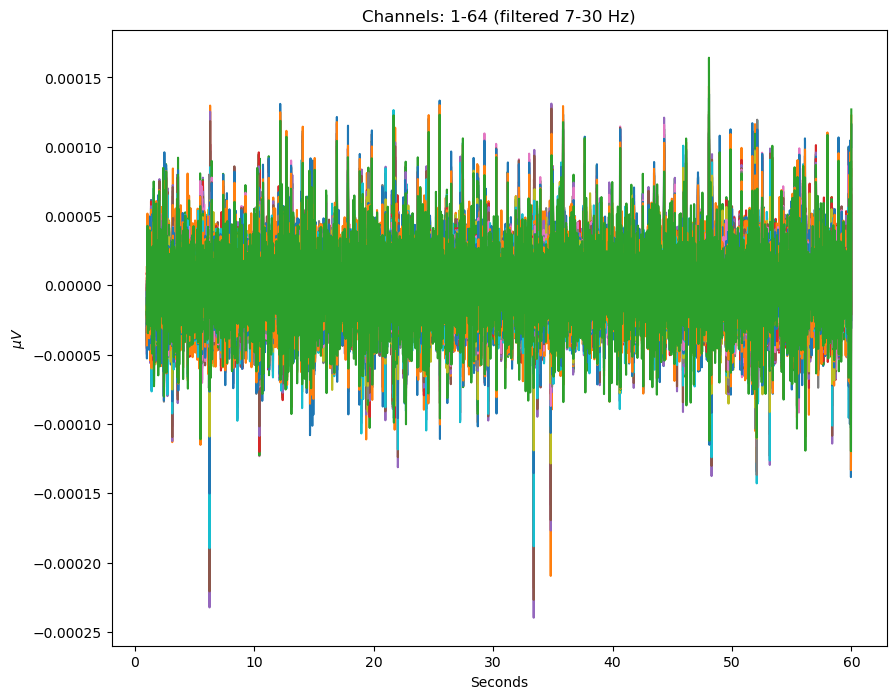

In [53]:
# Quick visualization of raw signal (first 60s)
raw_copy = raw_obj.copy().filter(7., 30., fir_design='firwin', skip_by_annotation='edge')
sfreq = raw_copy.info['sfreq']
data, times = raw_copy[:-1, int(sfreq * 1):int(sfreq * 60)]

fig = plt.subplots(figsize=(10, 8))
plt.plot(times, data.T)
plt.xlabel('Seconds')
plt.ylabel('$\\mu V$')
plt.title('Channels: 1-64 (filtered 7-30 Hz)')
plt.show()

Effective window size : 12.800 (s)
Plotting power spectral density (dB=True).


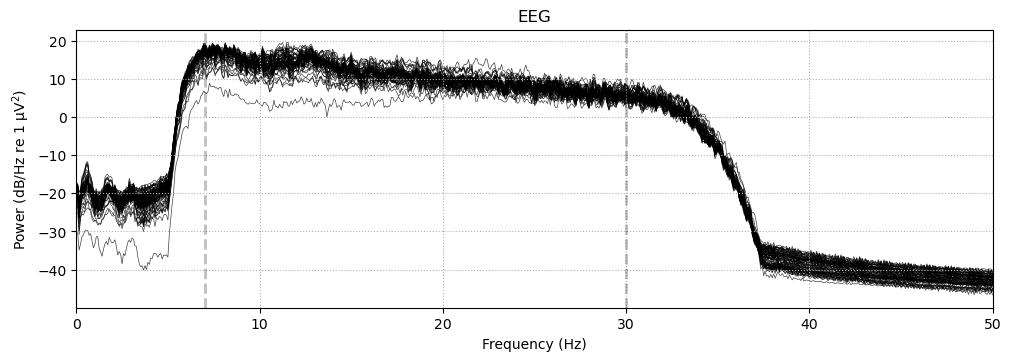

In [54]:
raw_copy.compute_psd(fmax=50).plot()
plt.show()

## 4. Preprocessing & Epoching — ALL subjects

For each subject:

1. Bandpass filter 7-30 Hz (mu + beta bands)
2. Extract events from annotations
3. Cut 4-second epochs around events
4. Collect X (data) and y (labels) with subject IDs


In [55]:
event_id = {'rest': 1, 'left_hand': 2, 'right_hand': 3}

all_X = []
all_y = []
all_subjects = []  # track which subject each epoch belongs to

skipped = []

for subject in tqdm(raw_data, desc="Epoching subjects"):
    try:
        raw = raw_data[subject].copy()
        raw.filter(7., 30., fir_design='firwin', skip_by_annotation='edge', verbose=False)

        events, event_ids = mne.events_from_annotations(raw, event_id='auto', verbose=False)

        epochs = mne.Epochs(raw, events, event_id, tmin=0.0, tmax=4.0,
                            baseline=None, preload=True, verbose=False)

        X = epochs.get_data().astype(np.float32)  # (n_epochs, 64, 641)
        y = epochs.events[:, -1] - 1               # 0=rest, 1=left, 2=right

        for ch in range(X.shape[1]):
            mean = X[:, ch, :].mean()
            std = X[:, ch, :].std()
            if std > 0:
                X[:, ch, :] = (X[:, ch, :] - mean) / std

        all_X.append(X)
        all_y.append(y)
        all_subjects.append(np.full(len(y), int(subject)))  # subject ID per epoch

    except Exception as e:
        skipped.append(subject)
        print(f"⚠️ Subject {subject} failed: {e}")

X_all = np.concatenate(all_X, axis=0)
y_all = np.concatenate(all_y, axis=0)
subjects_all = np.concatenate(all_subjects, axis=0)

# Balance classes by downsampling to smallest class 
print(f"\nBefore balancing: {np.bincount(y_all)}")
min_count = min(np.bincount(y_all))
balanced_idx = []
for cls in range(3):
    cls_idx = np.where(y_all == cls)[0]
    chosen = np.random.choice(cls_idx, size=min_count, replace=False)
    balanced_idx.append(chosen)
balanced_idx = np.concatenate(balanced_idx)
np.random.shuffle(balanced_idx)

X_all = X_all[balanced_idx]
y_all = y_all[balanced_idx]
subjects_all = subjects_all[balanced_idx]


print(f"\nTotal epochs: {X_all.shape[0]}")
print(f"Shape: {X_all.shape}")
print(f"Class distribution (after balancing): {np.bincount(y_all)}")
print(f"Unique subjects: {len(np.unique(subjects_all))}")
if skipped:
    print(f"Skipped subjects: {skipped}")

Epoching subjects: 100%|██████████| 106/106 [00:06<00:00, 15.32it/s]



Before balancing: [4768 2396 2352]

Total epochs: 7056
Shape: (7056, 64, 641)
Class distribution (after balancing): [2352 2352 2352]
Unique subjects: 106


## 5. Subject-based Train / Val / Test Split

Split **subjects** (not epochs) into train/val/test to prevent data leakage.


In [56]:
unique_subjects = np.unique(subjects_all)
np.random.shuffle(unique_subjects)

n = len(unique_subjects)
n_train = int(n * 0.7)
n_val = int(n * 0.15)

train_subjects = set(unique_subjects[:n_train])
val_subjects   = set(unique_subjects[n_train:n_train + n_val])
test_subjects  = set(unique_subjects[n_train + n_val:])

train_mask = np.isin(subjects_all, list(train_subjects))
val_mask   = np.isin(subjects_all, list(val_subjects))
test_mask  = np.isin(subjects_all, list(test_subjects))

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_val,   y_val   = X_all[val_mask],   y_all[val_mask]
X_test,  y_test  = X_all[test_mask],  y_all[test_mask]

print(f"Train: {len(X_train)} epochs from {len(train_subjects)} subjects")
print(f"Val:   {len(X_val)} epochs from {len(val_subjects)} subjects")
print(f"Test:  {len(X_test)} epochs from {len(test_subjects)} subjects")
print(f"\nTrain class dist: {np.bincount(y_train)}")
print(f"Val class dist:   {np.bincount(y_val)}")
print(f"Test class dist:  {np.bincount(y_test)}")

Train: 4924 epochs from 74 subjects
Val:   1003 epochs from 15 subjects
Test:  1129 epochs from 17 subjects

Train class dist: [1641 1642 1641]
Val class dist:   [335 335 333]
Test class dist:  [376 375 378]


## 6. Dataset & DataLoaders


In [57]:
class EEGDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray, augment=False):
        """
        X: numpy array (n_samples, n_channels, n_timepoints)
        y: numpy array (n_samples,)
        """
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.y[idx]
        if self.augment:
            # gaussian noise
            x += np.random.normal(0, 0.1, x.shape).astype(np.float32)
            # timeshift by randdom +- 20 samples
            shift = np.random.randint(-20, 21)
            x = np.roll(x, shift, axis=-1)
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

In [58]:
BATCH_SIZE = 64

train_dataset = EEGDataset(X_train, y_train)
val_dataset   = EEGDataset(X_val, y_val)
test_dataset  = EEGDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

Train batches: 77, Val batches: 16, Test batches: 18


## 7. EEGNet Model


In [59]:
# https://github.com/amrzhd/EEGNet/blob/main/EEGNet.py

class EEGNet(nn.Module):
    def __init__(self, chans=64, classes=3, time_points=641,
                 temp_kernel=80, f1=8, f2=16, d=2,
                 pk1=4, pk2=8, dropout_rate=0.5):
        super(EEGNet, self).__init__()

        # FC size after all pooling
        linear_size = (time_points // (pk1 * pk2)) * f2

        # Block 1: Temporal filtering
        self.block1 = nn.Sequential(
            nn.Conv2d(1, f1, (1, temp_kernel), padding='same', bias=False),
            nn.BatchNorm2d(f1),
        )

        # Block 2: Spatial filtering (depthwise)
        self.block2 = nn.Sequential(
            nn.Conv2d(f1, d * f1, (chans, 1), groups=f1, bias=False),
            nn.BatchNorm2d(d * f1),
            nn.ELU(),
            nn.AvgPool2d((1, pk1)),
            nn.Dropout(dropout_rate),
        )

        # Block 3: Separable conv
        self.block3 = nn.Sequential(
            nn.Conv2d(d * f1, d * f1, (1, 16), groups=d * f1, padding='same', bias=False),
            nn.Conv2d(d * f1, f2, 1, bias=False),
            nn.BatchNorm2d(f2),
            nn.ELU(),
            nn.AvgPool2d((1, pk2)),
            nn.Dropout(dropout_rate),
        )

        self.flatten = nn.Flatten()
        self.fc = nn.Linear(linear_size, classes)

    def forward(self, x):
        if x.dim() == 3:
            x = x.unsqueeze(1)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.flatten(x)
        x = self.fc(x)
        return x

## 8. Training & Evaluation Functions


In [60]:
def train_step(model, dataloader, loss_fn, optimizer, device):
    model.train()
    train_loss, train_acc = 0, 0
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        y_pred_class = y_pred.argmax(dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y)
    train_loss /= len(dataloader)
    train_acc /= len(dataloader)
    return train_loss, train_acc


def eval_step(model, dataloader, loss_fn, device):
    model.eval()
    eval_loss, eval_acc = 0, 0
    with torch.inference_mode():
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss = loss_fn(logits, y)
            eval_loss += loss.item()
            pred_labels = logits.argmax(dim=1)
            eval_acc += (pred_labels == y).sum().item() / len(pred_labels)
    eval_loss /= len(dataloader)
    eval_acc /= len(dataloader)
    return eval_loss, eval_acc


def train(model, train_dataloader, val_dataloader, test_dataloader,
          optimizer, loss_fn, scheduler, device, epochs=50, verbose=True):

    results = {
        "train_loss": [], "train_acc": [],
        "val_loss": [], "val_acc": [],
        "test_loss": [], "test_acc": [],
    }

    best_val_acc = 0.0
    best_model_state = None

    iterator = tqdm(range(epochs)) if verbose else range(epochs)
    for epoch in iterator:
        train_loss, train_acc = train_step(model, train_dataloader, loss_fn, optimizer, device)
        scheduler.step()
        val_loss, val_acc = eval_step(model, val_dataloader, loss_fn, device)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = copy.deepcopy(model.state_dict())

        if verbose:
            print(
                f"Epoch: {epoch+1:3d} | "
                f"train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f} | "
                f"val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f}"
            )

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["val_loss"].append(val_loss)
        results["val_acc"].append(val_acc)

    if best_model_state:
        model.load_state_dict(best_model_state)
    test_loss, test_acc = eval_step(model, test_dataloader, loss_fn, device)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)

    if verbose:
        print(f"\n{'='*50}")
        print(f"Best val_acc: {best_val_acc:.4f}")
        print(f"Final test_loss: {test_loss:.4f} | test_acc: {test_acc:.4f}")

    return results, best_val_acc

## 9. Single Run — Train on all subjects


In [ ]:
print(dir(epochs))
print(vars(epochs))

In [62]:
from sklearn.utils.class_weight import compute_class_weight

eeg_net = EEGNet().to(device)

# Weighted loss to handle any remaining imbalance after split 
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f"Class weights (64ch): {class_weights}")
loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor)

optimizer = torch.optim.Adam(eeg_net.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

Class weights (64ch): [1.00020313 0.99959399 1.00020313]


In [17]:
import torch
print(torch.cuda.get_device_name(0))
print(torch.cuda.get_device_capability(0))

NVIDIA GeForce RTX 5080
(12, 0)


In [18]:
import sys
print(sys.executable)

/opt/conda/bin/python


In [ ]:
results, best_val = train(
    model=eeg_net,
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    test_dataloader=test_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    device=device,
    scheduler=scheduler,
    epochs=50
)

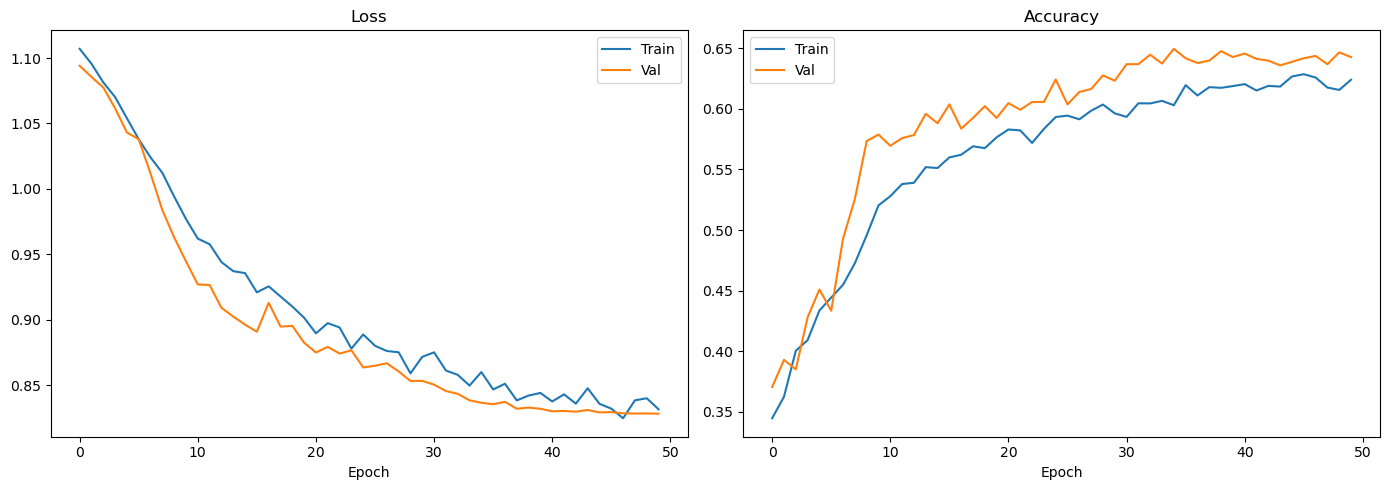

In [20]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(results['train_loss'], label='Train')
axes[0].plot(results['val_loss'], label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(results['train_acc'], label='Train')
axes[1].plot(results['val_acc'], label='Val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

## 10. Subject-based K-Fold Cross-Validation

GroupKFold ensures no subject appears in both train and val within a fold.


In [94]:
from sklearn.utils.class_weight import compute_class_weight

def cross_validate_subjects(X, y, subjects, n_splits=5, epochs=50,
                            lr=0.001, batch_size=64, dropout_rate=0.5,
                            f1=8, f2=16, d=2, temp_kernel=80, chans=64, classes=3):
    """
    Subject-based K-Fold cross-validation.
    Groups = subject IDs, so no subject leaks between folds.
    """
    gkf = GroupKFold(n_splits=n_splits)
    fold_results = []

    for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=subjects)):
        print(f"\n{'='*50}")
        print(f"Fold {fold+1}/{n_splits}")
        print(f"Train: {len(train_idx)} epochs, Val: {len(val_idx)} epochs")
        print(f"Train subjects: {len(np.unique(subjects[train_idx]))}, "
              f"Val subjects: {len(np.unique(subjects[val_idx]))}")

        X_tr, y_tr = X[train_idx], y[train_idx]
        X_vl, y_vl = X[val_idx], y[val_idx]

        train_ds = EEGDataset(X_tr, y_tr)
        val_ds   = EEGDataset(X_vl, y_vl)

        train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        val_dl   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)

        model = EEGNet(chans=chans, classes=classes, f1=f1, f2=f2, d=d,
               dropout_rate=dropout_rate, temp_kernel=temp_kernel).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        fold_weights = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
        loss_fn = nn.CrossEntropyLoss(
            weight=torch.tensor(fold_weights, dtype=torch.float32).to(device)
        )
        print(f"Fold {fold+1} class weights: {fold_weights}")

        best_val_acc = 0.0
        for epoch in range(epochs):
            train_step(model, train_dl, loss_fn, optimizer, device)
            val_loss, val_acc = eval_step(model, val_dl, loss_fn, device)
            if val_acc > best_val_acc:
                best_val_acc = val_acc

        print(f"Fold {fold+1} best val_acc: {best_val_acc:.4f}")
        fold_results.append(best_val_acc)

    mean_acc = np.mean(fold_results)
    std_acc = np.std(fold_results)
    print(f"\n{'='*50}")
    print(f"Cross-validation results ({n_splits} folds):")
    print(f"Fold accuracies: {[f'{x:.4f}' for x in fold_results]}")
    print(f"Mean: {mean_acc:.4f} ± {std_acc:.4f}")

    return fold_results, mean_acc, std_acc

In [22]:
# Use train+val data for CV (keep test set untouched)
cv_mask = train_mask | val_mask
X_cv = X_all[cv_mask]
y_cv = y_all[cv_mask]
subjects_cv = subjects_all[cv_mask]

fold_results, mean_acc, std_acc = cross_validate_subjects(
    X_cv, y_cv, subjects_cv,
    n_splits=5, epochs=50, lr=0.001
)


Fold 1/5
Train: 4729 epochs, Val: 1198 epochs
Train subjects: 71, Val subjects: 18
Fold 1 class weights: [1.00021151 1.00148242 0.99831117]
Fold 1 best val_acc: 0.5855

Fold 2/5
Train: 4729 epochs, Val: 1198 epochs
Train subjects: 71, Val subjects: 18
Fold 2 class weights: [1.00084656 0.99831117 1.00084656]
Fold 2 best val_acc: 0.6167

Fold 3/5
Train: 4730 epochs, Val: 1197 epochs
Train subjects: 71, Val subjects: 18
Fold 3 class weights: [0.99537037 0.99978863 1.00488634]
Fold 3 best val_acc: 0.6713

Fold 4/5
Train: 4731 epochs, Val: 1196 epochs
Train subjects: 71, Val subjects: 18
Fold 4 class weights: [0.99558081 1.00126984 1.00318066]
Fold 4 best val_acc: 0.6503

Fold 5/5
Train: 4789 epochs, Val: 1138 epochs
Train subjects: 72, Val subjects: 17
Fold 5 class weights: [1.00715037 0.99584113 0.99708516]
Fold 5 best val_acc: 0.6724

Cross-validation results (5 folds):
Fold accuracies: ['0.5855', '0.6167', '0.6713', '0.6503', '0.6724']
Mean: 0.6392 ± 0.0336


## 11. Grid Search over Hyperparameters

Uses 3-fold subject-based CV for each hyperparameter combo to keep runtime manageable.


In [ ]:
param_grid = {
    'lr':           [0.001, 0.0005],
    'dropout_rate': [0.25, 0.5],
    'f1':           [8, 16],
    'd':            [2, 4],
}

# Generate all combinations
keys = list(param_grid.keys())
combos = list(itertools.product(*param_grid.values()))
print(f"Total hyperparameter combinations: {len(combos)}")

grid_results = []

for i, combo in enumerate(combos):
    params = dict(zip(keys, combo))
    f2 = params['f1'] * params['d']  # f2 = f1 * d (standard EEGNet convention)
    
    print(f"\n{'#'*60}")
    print(f"Combo {i+1}/{len(combos)}: {params}, f2={f2}")

    _, mean_acc, std_acc = cross_validate_subjects(
        X_cv, y_cv, subjects_cv,
        n_splits=3,
        epochs=30,       # fewer epochs for grid search speed
        lr=params['lr'],
        dropout_rate=params['dropout_rate'],
        f1=params['f1'],
        f2=f2,
        d=params['d'],
    )

    grid_results.append({
        **params, 'f2': f2,
        'mean_acc': mean_acc, 'std_acc': std_acc
    })

In [24]:
grid_df = pd.DataFrame(grid_results).sort_values('mean_acc', ascending=False)
print("\nGrid Search Results (sorted by mean CV accuracy):")
print(grid_df.to_string(index=False))


Grid Search Results (sorted by mean CV accuracy):
    lr  dropout_rate  f1  d  f2  mean_acc  std_acc
0.0005          0.25  16  4  64  0.669369 0.002976
0.0010          0.25   8  4  32  0.665856 0.018804
0.0010          0.25  16  4  64  0.660402 0.005392
0.0005          0.25  16  2  32  0.657016 0.016437
0.0010          0.25  16  2  32  0.656414 0.005111
0.0010          0.25   8  2  16  0.645911 0.005466
0.0010          0.50  16  4  64  0.642037 0.005134
0.0005          0.25   8  4  32  0.635505 0.009102
0.0005          0.50  16  4  64  0.634820 0.025138
0.0010          0.50   8  4  32  0.626337 0.033936
0.0005          0.50  16  2  32  0.616754 0.014966
0.0005          0.25   8  2  16  0.616525 0.014051
0.0010          0.50  16  2  32  0.615069 0.019884
0.0010          0.50   8  2  16  0.590382 0.018818
0.0005          0.50   8  4  32  0.588709 0.023616
0.0005          0.50   8  2  16  0.554128 0.003257


## 12. Final Model — Retrain with best hyperparameters & evaluate on test set


In [ ]:
best_params = grid_df.iloc[0].to_dict()
print(f"Best hyperparameters: {best_params}")

final_model = EEGNet(
    f1=int(best_params['f1']),
    f2=int(best_params['f2']),
    d=int(best_params['d']),
    dropout_rate=best_params['dropout_rate'],
).to(device)

# Train+val combined for final training
final_train_ds = EEGDataset(X_all[cv_mask], y_all[cv_mask])
final_train_dl = DataLoader(final_train_ds, batch_size=64, shuffle=True)

final_optimizer = torch.optim.Adam(final_model.parameters(), lr=best_params['lr'])
final_weights = compute_class_weight('balanced', classes=np.unique(y_all[cv_mask]), y=y_all[cv_mask])
final_loss_fn = nn.CrossEntropyLoss(
    weight=torch.tensor(final_weights, dtype=torch.float32).to(device)
)

# Train (use test_loader as both val and test since we already selected params via CV)
final_results, _ = train(
    model=final_model,
    train_dataloader=final_train_dl,
    val_dataloader=test_loader,
    test_dataloader=test_loader,
    optimizer=final_optimizer,
    scheduler=scheduler,
    loss_fn=final_loss_fn,
    device=device,
    epochs=50
)


Classification Report:
              precision    recall  f1-score   support

        rest       0.76      0.59      0.66       376
   left_hand       0.71      0.77      0.74       375
  right_hand       0.71      0.80      0.75       378

    accuracy                           0.72      1129
   macro avg       0.72      0.72      0.72      1129
weighted avg       0.72      0.72      0.72      1129



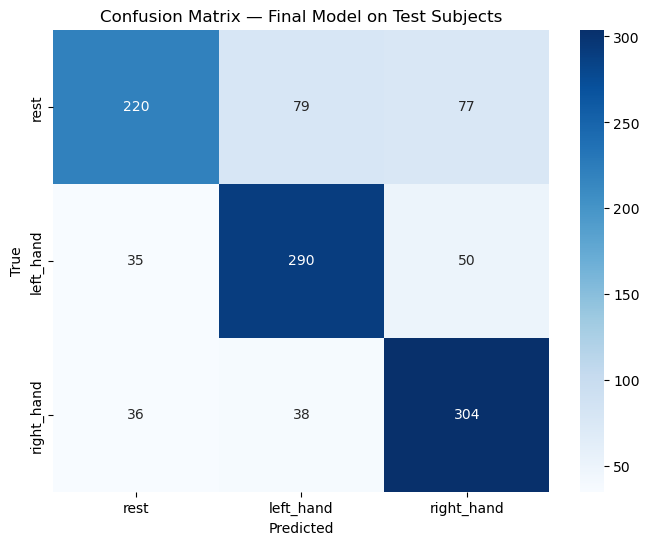

In [26]:
# Final evaluation with classification report
final_model.eval()
all_preds = []
all_labels = []

with torch.inference_mode():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        logits = final_model(X_batch)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print("\nClassification Report:")
print(classification_report(all_labels, all_preds,
                            target_names=['rest', 'left_hand', 'right_hand']))


cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['rest', 'left_hand', 'right_hand'],
            yticklabels=['rest', 'left_hand', 'right_hand'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix — Final Model on Test Subjects')
plt.show()

In [27]:
torch.save(final_model.state_dict(), 'eegnet_best.pth')
print("Model saved to eegnet_best.pth")

Model saved to eegnet_best.pth


## 13. Trying out common spatial patterns (CSP)


### What is Common Spatial Pattern (CSP)?

CSP is a spatial filtering technique used to enhance the discriminative power of EEG signals. It is particularly useful for binary classification problems, such as distinguishing between left-hand and right-hand motor imagery. CSP works by finding spatial filters that maximize the variance for one class while minimizing it for the other.

### How Does CSP Work?

Data Preparation: EEG data is segmented into epochs corresponding to different tasks or stimuli.
Covariance Calculation: The covariance matrices of the epochs for each class are calculated.
Eigenvalue Decomposition: The composite covariance matrix is decomposed into eigenvalues and eigenvectors.
Spatial Filters: Spatial filters are derived from the eigenvectors, which are then used to project the original EEG data into a new space that maximizes class separability.
Feature Extraction: The variance of the filtered signals is used as features for classification.

### Why Use CSP?

Enhances Discriminability: CSP improves the separation between classes, making it easier for classifiers to distinguish between different mental states.
Reduces Dimensionality: By focusing on the most significant spatial patterns, CSP reduces the complexity of the data.
Improves Classification Accuracy: CSP has been shown to significantly improve the performance of classifiers in BCI applications.

[source](https://medium.com/@manishthilagar/understanding-common-spatial-pattern-csp-with-the-mne-library-for-eeg-data-analysis-aa6693f3d49d)


### 13.1 One vs Rest CSP

It's a technique allowing to use binary classificators for multiclasiffication problems.
For example, if problem consists 3 classes it will train separate classificator for each of possible pairs. Then when we try to predict each model returns output and proble is classified to the one class taht was given the highest probability.


In [ ]:
from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import cross_val_score, GroupKFold


csp_non_reg = CSP(n_components=4, reg=None, log=True, norm_trace=False)
csp_ledoit_wolf = CSP(n_components=6, reg="ledoit_wolf", log=True, norm_trace=False)
lda = LinearDiscriminantAnalysis()

pipe = Pipeline([
    ('csp without reg', csp_non_reg),
    ('csp with ledoit wold', csp_ledoit_wolf),
    ('classifier', OneVsRestClassifier(lda))
])


gkf = GroupKFold(n_splits=5)
scores = cross_val_score(pipe, X_all, y_all, cv=gkf, groups=subjects_all, scoring='accuracy')
print(f"CSP+LDA OvR: {scores.mean():.4f} ± {scores.std():.4f}")

### 13.2 Pairwise

It works yb making 3 binary classifiers: left vs right, left vs rest, right vs rest. Each gives 4 features and we merge them into 12 features that we put into one classfier.


In [20]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import classification_report, confusion_matrix
from mne.decoding import CSP
import time

# We'll use the Pairwise CSP approach to extract features for all ML models.
# This gives us 12 features per epoch (3 class pairs × 4 CSP components).

class MultiClassCSP(BaseEstimator, TransformerMixin):
    """
    Pairwise CSP for multiclass problems.
    Trains a separate binary CSP for each pair of classes,
    then concatenates all features into one vector.
    """
    def __init__(self, n_components=4, reg='ledoit_wolf'):
        self.n_components = n_components
        self.reg = reg
        self.pairs = [(0, 1), (0, 2), (1, 2)]
        self.csps = None

    def fit(self, X, y):
        self.csps = []
        for (c1, c2) in self.pairs:
            csp = CSP(n_components=self.n_components, reg=self.reg,
                      log=True, norm_trace=False)
            mask = (y == c1) | (y == c2)
            csp.fit(X[mask], y[mask])
            self.csps.append(csp)
        return self

    def transform(self, X):
        features = [csp.transform(X) for csp in self.csps]
        return np.concatenate(features, axis=1)


# Extract features once (saves time vs re-extracting in every CV fold)
# We use train+val for CV, test stays untouched
cv_mask = train_mask | val_mask
X_cv = X_all[cv_mask]
y_cv = y_all[cv_mask]
subjects_cv = subjects_all[cv_mask]

gkf = GroupKFold(n_splits=5)

print(f"CV data: {X_cv.shape[0]} epochs, {len(np.unique(subjects_cv))} subjects")
print(f"Test data: {X_test.shape[0]} epochs")

CV data: 5927 epochs, 89 subjects
Test data: 1129 epochs


## 14. Classical ML Models — Grid Search with Subject-based CV

Below we benchmark several classical ML approaches on the CSP-extracted features.
Each model is explained and then grid-searched with GroupKFold to prevent subject leakage.
We compare them all against each other and against the EEGNet deep learning approach.


In [18]:
models = {
    # ---------------------------------------------------------------
    # LDA — Linear Discriminant Analysis
    # Finds linear combinations of features that best separate classes.
    # Assumes features are normally distributed with equal covariance
    # across classes. Simple, fast, and a standard BCI baseline.
    # ---------------------------------------------------------------
    'LDA': {
    'model': LinearDiscriminantAnalysis(),
    'params': [
        {
            'classifier__solver': ['svd'],
            'classifier__shrinkage': [None],
            'csp__n_components': [4, 6],
        },
        {
            'classifier__solver': ['lsqr'],
            'classifier__shrinkage': [None, 'auto'],
            'csp__n_components': [4, 6],
        },
    ]
    },

    # ---------------------------------------------------------------
    # SVM — Support Vector Machine
    # Finds the hyperplane that maximizes the margin between classes.
    # With RBF kernel, it can learn non-linear decision boundaries by
    # mapping data to a higher-dimensional space. The C parameter
    # controls the trade-off between margin width and misclassification.
    # ---------------------------------------------------------------
    'SVM': {
        'model': SVC(probability=True, random_state=42, class_weight='balanced'),
        'params': {
            'classifier__C': [0.1, 1.0, 10.0],
            'classifier__kernel': ['rbf', 'linear'],
            'classifier__gamma': ['scale', 'auto'],
            'csp__n_components': [4, 6],
        }
    },

    # ---------------------------------------------------------------
    # Random Forest
    # An ensemble of decision trees, each trained on a random subset
    # of data and features. Final prediction = majority vote.
    # Resistant to overfitting due to averaging. Handles non-linear
    # relationships well without feature scaling.
    # ---------------------------------------------------------------
    'RandomForest': {
        'model': RandomForestClassifier(random_state=42, class_weight='balanced'),
        'params': {
            'classifier__n_estimators': [100, 200],
            'classifier__max_depth': [5, 10, None],
            'classifier__min_samples_leaf': [1, 5],
            'csp__n_components': [4, 6],
        }
    },

    # ---------------------------------------------------------------
    # KNN — K-Nearest Neighbors
    # Classifies a sample by majority vote of its K closest neighbors
    # in feature space. Simple, non-parametric — no training phase,
    # just memorizes data. Distance metric and K are critical.
    # Works well when decision boundaries are irregular.
    # ---------------------------------------------------------------
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {
            'classifier__n_neighbors': [3, 5, 7, 11],
            'classifier__weights': ['uniform', 'distance'],
            'classifier__metric': ['euclidean', 'manhattan'],
            'csp__n_components': [4, 6],
        }
    },

    # ---------------------------------------------------------------
    # Gradient Boosting
    # Builds trees sequentially — each new tree corrects the errors
    # of the previous ones. Learning rate controls how much each tree
    # contributes. Generally more accurate than Random Forest but
    # slower and more prone to overfitting without tuning.
    # ---------------------------------------------------------------
    'GradientBoosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {
            'classifier__n_estimators': [100, 200],
            'classifier__learning_rate': [0.01, 0.1],
            'classifier__max_depth': [3, 5],
            'csp__n_components': [4, 6],
        }
    },

    # ---------------------------------------------------------------
    # Logistic Regression
    # Despite the name, it's a classifier. Models the probability of
    # each class as a logistic (sigmoid) function of a linear
    # combination of features. Regularization (C) prevents overfitting.
    # Fast, interpretable, works well with CSP features.
    # ---------------------------------------------------------------
    'LogisticRegression': {
        'model': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
        'params': {
            'classifier__C': [0.01, 0.1, 1.0, 10.0],
            'classifier__penalty': ['l1', 'l2'],
            'classifier__solver': ['saga'],
            'csp__n_components': [4, 6],
        }
    },

    # ---------------------------------------------------------------
    # MLP — Multi-Layer Perceptron (shallow neural network)
    # A feedforward neural network with 1-2 hidden layers.
    # Can learn non-linear patterns. Acts as a bridge between
    # classical ML and deep learning. Needs feature scaling.
    # ---------------------------------------------------------------
    'MLP': {
        'model': MLPClassifier(max_iter=500, random_state=42, early_stopping=True),
        'params': {
            'classifier__hidden_layer_sizes': [(64,), (128,), (64, 32)],
            'classifier__alpha': [0.0001, 0.001],
            'classifier__learning_rate_init': [0.001, 0.01],
            'csp__n_components': [4, 6],
        }
    },
}

total_combos = 0
for m in models.values():
    p = m['params']
    if isinstance(p, list):
        for param_dict in p:
            total_combos += np.prod([len(v) for v in param_dict.values()])
    else:
        total_combos += np.prod([len(v) for v in p.values()])
print(f"Total hyperparameter combinations across all models: {int(total_combos)}")

Total hyperparameter combinations across all models: 142


In [ ]:
all_results = []

for name, config in models.items():
    print(f"\n{'#'*60}")
    print(f"  {name}")
    print(f"{'#'*60}")

    pipe = Pipeline([
        ('csp', MultiClassCSP(n_components=4, reg='ledoit_wolf')),
        ('scaler', StandardScaler()),
        ('classifier', config['model']),
    ])

    grid = GridSearchCV(
        pipe,
        param_grid=config['params'],
        cv=gkf,
        scoring='accuracy',
        n_jobs=-1,
        verbose=0,
        error_score='raise',
    )

    start = time.time()
    grid.fit(X_cv, y_cv, groups=subjects_cv)
    elapsed = time.time() - start

    print(f"Best params: {grid.best_params_}")
    print(f"Best CV accuracy: {grid.best_score_:.4f}")
    print(f"Time: {elapsed:.1f}s")

    all_results.append({
        'model': name,
        'best_cv_acc': grid.best_score_,
        'best_params': grid.best_params_,
        'time_s': elapsed,
        'grid_obj': grid,
    })


############################################################
  LDA
############################################################
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None


In [ ]:

results_df = pd.DataFrame([
    {'Model': r['model'], 'CV Accuracy': r['best_cv_acc'], 'Time (s)': r['time_s']}
    for r in all_results
]).sort_values('CV Accuracy', ascending=False)

print("\n" + "="*60)
print("  ML Model Comparison (5-fold subject-based CV)")
print("="*60)
print(results_df.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(results_df)))
bars = ax.barh(results_df['Model'], results_df['CV Accuracy'], color=colors)
ax.set_xlabel('CV Accuracy')
ax.set_title('ML Model Comparison — CSP + Subject-based CV')
ax.set_xlim(0.3, max(results_df['CV Accuracy']) + 0.05)
for bar, acc in zip(bars, results_df['CV Accuracy']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{acc:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
best_result = max(all_results, key=lambda x: x['best_cv_acc'])
best_grid = best_result['grid_obj']
best_model = best_grid.best_estimator_

print(f"Best model: {best_result['model']}")
print(f"Best CV accuracy: {best_result['best_cv_acc']:.4f}")
print(f"Best params: {best_result['best_params']}")

# Predict on test set
y_pred = best_model.predict(X_test)

print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                            target_names=['rest', 'left_hand', 'right_hand']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['rest', 'left_hand', 'right_hand'],
            yticklabels=['rest', 'left_hand', 'right_hand'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix — {best_result["model"]} on Test Subjects')
plt.show()

## 15. Motor Cortex Channels — Full Pipeline

We repeat the entire pipeline (epoching, splitting, EEGNet, CV, grid search, ML models)
but using only the 21 channels over the sensorimotor cortex (FC, C, CP rows).
This reduces noise from irrelevant brain regions and speeds up training.


### 15.1 Epoching with motor channels + per-subject normalization


In [64]:
motor_channels = [
    'Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.',
    'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..',
    'Cp5.', 'Cp3.', 'Cp1.', 'Cpz.', 'Cp2.', 'Cp4.', 'Cp6.',
]

event_id = {'rest': 1, 'left_hand': 2, 'right_hand': 3}

all_X = []
all_y = []
all_subjects = []

skipped = []

for subject in tqdm(raw_data, desc="Epoching subjects"):
    try:
        raw = raw_data[subject].copy()
        raw.pick(motor_channels)
        raw.filter(7., 30., fir_design='firwin', skip_by_annotation='edge', verbose=False)

        events, event_ids = mne.events_from_annotations(raw, event_id='auto', verbose=False)

        epochs = mne.Epochs(raw, events, event_id, tmin=0.0, tmax=4.0,
                            baseline=None, preload=True, verbose=False)

        X = epochs.get_data().astype(np.float32)  # (n_epochs, 21, 641)
        y = epochs.events[:, -1] - 1               # 0=rest, 1=left, 2=right

        # Per-subject normalization (preserves within-subject ERD differences)
        for ch in range(X.shape[1]):
            mean = X[:, ch, :].mean()
            std = X[:, ch, :].std()
            if std > 0:
                X[:, ch, :] = (X[:, ch, :] - mean) / std

        all_X.append(X)
        all_y.append(y)
        all_subjects.append(np.full(len(y), int(subject)))

    except Exception as e:
        skipped.append(subject)
        print(f"⚠️ Subject {subject} failed: {e}")

X_all = np.concatenate(all_X, axis=0)
y_all = np.concatenate(all_y, axis=0)
subjects_all = np.concatenate(all_subjects, axis=0)

# Balance classes by downsampling to smallest class
min_count = min(np.bincount(y_all))
balanced_idx = []
for cls in range(3):
    cls_idx = np.where(y_all == cls)[0]
    chosen = np.random.choice(cls_idx, size=min_count, replace=False)
    balanced_idx.append(chosen)
balanced_idx = np.concatenate(balanced_idx)
np.random.shuffle(balanced_idx)

X_all = X_all[balanced_idx]
y_all = y_all[balanced_idx]
subjects_all = subjects_all[balanced_idx]

print(f"\nChannels used ({len(motor_channels)}): {motor_channels}")
print(f"Total epochs: {X_all.shape[0]}")
print(f"Shape: {X_all.shape}")
print(f"Class distribution: {np.bincount(y_all)}")
print(f"Unique subjects: {len(np.unique(subjects_all))}")
if skipped:
    print(f"Skipped subjects: {skipped}")

Epoching subjects: 100%|██████████| 106/106 [00:02<00:00, 37.44it/s]



Channels used (21): ['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..', 'Cp5.', 'Cp3.', 'Cp1.', 'Cpz.', 'Cp2.', 'Cp4.', 'Cp6.']
Total epochs: 7056
Shape: (7056, 21, 641)
Class distribution: [2352 2352 2352]
Unique subjects: 106


### 15.2 Subject-based split


In [65]:
unique_subjects = np.unique(subjects_all)
np.random.shuffle(unique_subjects)

n = len(unique_subjects)
n_train = int(n * 0.7)
n_val = int(n * 0.15)

train_subjects = set(unique_subjects[:n_train])
val_subjects   = set(unique_subjects[n_train:n_train + n_val])
test_subjects  = set(unique_subjects[n_train + n_val:])

train_mask = np.isin(subjects_all, list(train_subjects))
val_mask   = np.isin(subjects_all, list(val_subjects))
test_mask  = np.isin(subjects_all, list(test_subjects))

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_val,   y_val   = X_all[val_mask],   y_all[val_mask]
X_test,  y_test  = X_all[test_mask],  y_all[test_mask]

print(f"Train: {len(X_train)} epochs from {len(train_subjects)} subjects")
print(f"Val:   {len(X_val)} epochs from {len(val_subjects)} subjects")
print(f"Test:  {len(X_test)} epochs from {len(test_subjects)} subjects")
print(f"\nTrain class dist: {np.bincount(y_train)}")
print(f"Val class dist:   {np.bincount(y_val)}")
print(f"Test class dist:  {np.bincount(y_test)}")

Train: 4958 epochs from 74 subjects
Val:   982 epochs from 15 subjects
Test:  1116 epochs from 17 subjects

Train class dist: [1672 1643 1643]
Val class dist:   [315 328 339]
Test class dist:  [365 381 370]


### 15.3 DataLoaders


In [66]:
BATCH_SIZE = 64

train_dataset = EEGDataset(X_train, y_train)
val_dataset   = EEGDataset(X_val, y_val)
test_dataset  = EEGDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

Train batches: 78, Val batches: 16, Test batches: 18


### 15.4 EEGNet single run (21 channels)


In [67]:
from sklearn.utils.class_weight import compute_class_weight

class_weights_21ch = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_21ch_tensor = torch.tensor(class_weights_21ch, dtype=torch.float32).to(device)
print(f"Class weights (21ch): {class_weights_21ch}")

Class weights (21ch): [0.988437   1.00588355 1.00588355]


In [ ]:
eeg_net = EEGNet(chans=21, classes=3).to(device)

loss_fn = nn.CrossEntropyLoss(weight=class_weights_21ch_tensor)
optimizer = torch.optim.Adam(eeg_net.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

results, best_val = train(
    model=eeg_net,
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    test_dataloader=test_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    scheduler=scheduler,
    device=device,
    epochs=55
)

### 15.5 Plot training curves


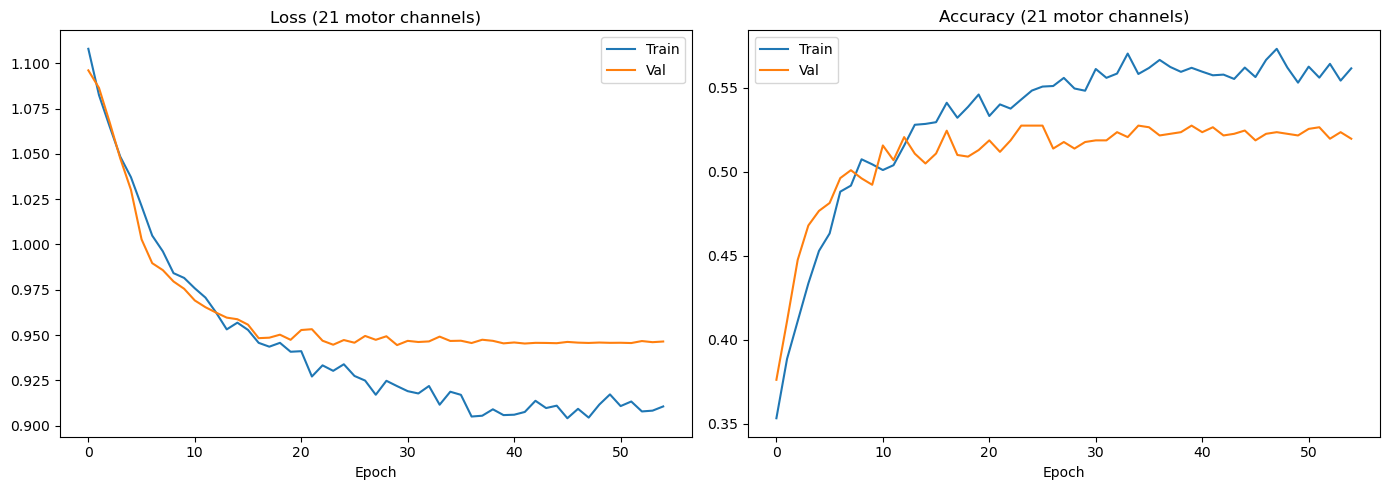

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(results['train_loss'], label='Train')
axes[0].plot(results['val_loss'], label='Val')
axes[0].set_title('Loss (21 motor channels)')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(results['train_acc'], label='Train')
axes[1].plot(results['val_acc'], label='Val')
axes[1].set_title('Accuracy (21 motor channels)')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

### 15.6 Test evaluation


In [71]:
test_loss, test_acc = eval_step(eeg_net, test_loader, loss_fn, device)
print(f"Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")

eeg_net.eval()
all_preds, all_labels = [], []
with torch.inference_mode():
    for X_batch, y_batch in test_loader:
        preds = eeg_net(X_batch.to(device)).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

print(classification_report(all_preds, all_labels,
                            target_names=['rest', 'left_hand', 'right_hand']))

Test loss: 1.0472 | Test acc: 0.4531
              precision    recall  f1-score   support

        rest       0.31      0.50      0.38       222
   left_hand       0.49      0.44      0.46       421
  right_hand       0.56      0.44      0.49       473

    accuracy                           0.45      1116
   macro avg       0.45      0.46      0.44      1116
weighted avg       0.48      0.45      0.46      1116



## 15.7 Subject-based CV (21 channels)


In [72]:
cv_mask = train_mask | val_mask

fold_results, mean_acc, std_acc = cross_validate_subjects(
    X_all[cv_mask], y_all[cv_mask], subjects_all[cv_mask],
    n_splits=5, epochs=50, lr=0.001,
    f1=8, f2=16, d=2, chans=21
)


Fold 1/5
Train: 4742 epochs, Val: 1198 epochs
Train subjects: 71, Val subjects: 18
Fold 1 class weights: [0.99538203 1.00423549 1.00042194]
Fold 1 best val_acc: 0.5345

Fold 2/5
Train: 4799 epochs, Val: 1141 epochs
Train subjects: 72, Val subjects: 17
Fold 2 class weights: [0.99979167 1.00418498 0.99605645]
Fold 2 best val_acc: 0.5620

Fold 3/5
Train: 4739 epochs, Val: 1201 epochs
Train subjects: 71, Val subjects: 18
Fold 3 class weights: [0.99663512 1.00487701 0.99852507]
Fold 3 best val_acc: 0.5936

Fold 4/5
Train: 4740 epochs, Val: 1200 epochs
Train subjects: 71, Val subjects: 18
Fold 4 class weights: [0.99558916 1.00572884 0.99873578]
Fold 4 best val_acc: 0.5299

Fold 5/5
Train: 4740 epochs, Val: 1200 epochs
Train subjects: 71, Val subjects: 18
Fold 5 class weights: [0.99496222 1.00381194 1.00126743]
Fold 5 best val_acc: 0.5863

Cross-validation results (5 folds):
Fold accuracies: ['0.5345', '0.5620', '0.5936', '0.5299', '0.5863']
Mean: 0.5613 ± 0.0260


### 15.8 EEGNet grid search (21 channels)


In [ ]:
param_grid = {
    'lr':           [0.005, 0.001, 0.0005],
    'dropout_rate': [0.25, 0.5],
    'f1':           [8, 16],
    'd':            [2, 4],
}

keys = list(param_grid.keys())
combos = list(itertools.product(*param_grid.values()))
print(f"Total combinations: {len(combos)}")

grid_results = []
for i, combo in enumerate(combos):
    params = dict(zip(keys, combo))
    f2 = params['f1'] * params['d']

    print(f"\n{'#'*60}")
    print(f"Combo {i+1}/{len(combos)}: {params}, f2={f2}")

    _, mean_acc, std_acc = cross_validate_subjects(
        X_all[cv_mask], y_all[cv_mask], subjects_all[cv_mask],
        n_splits=3, epochs=30,
        lr=params['lr'], dropout_rate=params['dropout_rate'],
        f1=params['f1'], f2=f2, d=params['d'],
        chans=21,
    )
    grid_results.append({**params, 'f2': f2, 'mean_acc': mean_acc, 'std_acc': std_acc})

grid_df = pd.DataFrame(grid_results).sort_values('mean_acc', ascending=False)
print("\nEEGNet Grid Search Results (21 motor channels):")
print(grid_df.to_string(index=False))

### 15.9 Final EEGNet with best params


In [ ]:
best_params = grid_df.iloc[0].to_dict()
print(f"Best: {best_params}")

final_model = EEGNet(
    chans=21,
    f1=int(best_params['f1']), f2=int(best_params['f2']),
    d=int(best_params['d']), dropout_rate=best_params['dropout_rate'],
).to(device)

final_train_dl = DataLoader(EEGDataset(X_all[cv_mask], y_all[cv_mask]),
                            batch_size=64, shuffle=True)
final_optimizer = torch.optim.Adam(final_model.parameters(), lr=best_params['lr'])
final_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(final_optimizer, T_max=50)
loss_fn=nn.CrossEntropyLoss(
    weight=torch.tensor(
        compute_class_weight('balanced', classes=np.unique(y_all[cv_mask]), y=y_all[cv_mask]),
        dtype=torch.float32
    ).to(device)
)

final_results, _ = train(
    model=final_model,
    train_dataloader=final_train_dl,
    val_dataloader=test_loader, test_dataloader=test_loader,
    optimizer=final_optimizer, loss_fn=loss_fn,
    scheduler=final_scheduler, device=device, epochs=50
)

### 15.10 Final EEGNet test evaluation + confusion matrix


              precision    recall  f1-score   support

        rest       0.61      0.52      0.56       365
   left_hand       0.64      0.63      0.63       381
  right_hand       0.59      0.69      0.64       370

    accuracy                           0.61      1116
   macro avg       0.61      0.61      0.61      1116
weighted avg       0.61      0.61      0.61      1116



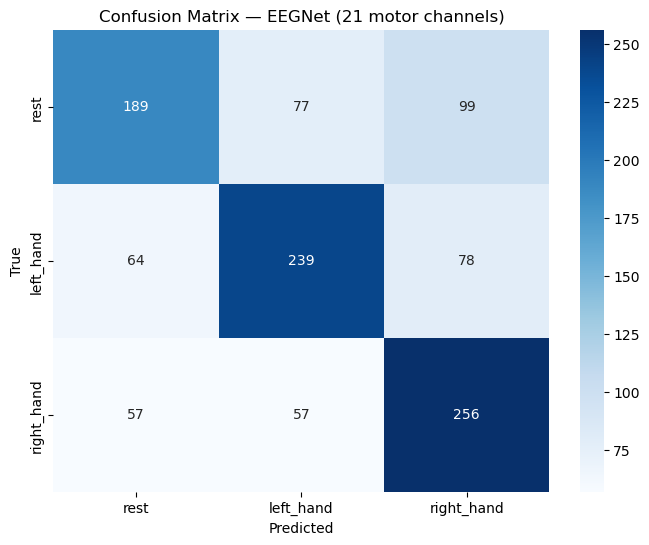

In [75]:
final_model.eval()
all_preds, all_labels = [], []
with torch.inference_mode():
    for X_batch, y_batch in test_loader:
        preds = final_model(X_batch.to(device)).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

print(classification_report(all_labels, all_preds,
                            target_names=['rest', 'left_hand', 'right_hand']))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['rest', 'left_hand', 'right_hand'],
            yticklabels=['rest', 'left_hand', 'right_hand'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix — EEGNet (21 motor channels)')
plt.show()

### 15.11 CSP OvR (21 channels)


In [ ]:
from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import cross_val_score, GroupKFold

csp = CSP(n_components=6, reg='ledoit_wolf', log=True, norm_trace=False)
lda = LinearDiscriminantAnalysis()

pipe = Pipeline([
    ('csp', csp),
    ('classifier', OneVsRestClassifier(lda))
])

gkf = GroupKFold(n_splits=5)
scores = cross_val_score(pipe, X_all[cv_mask], y_all[cv_mask],
                         cv=gkf, groups=subjects_all[cv_mask], scoring='accuracy')
print(f"CSP+LDA OvR (21ch): {scores.mean():.4f} ± {scores.std():.4f}")

### 15.12 CSP Pairwise + ML grid search (21 channels)


In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
import time

class MultiClassCSP(BaseEstimator, TransformerMixin):
    def __init__(self, n_components=4, reg='ledoit_wolf'):
        self.n_components = n_components
        self.reg = reg
        self.pairs = [(0, 1), (0, 2), (1, 2)]
        self.csps = None

    def fit(self, X, y):
        self.csps = []
        for (c1, c2) in self.pairs:
            csp = CSP(n_components=self.n_components, reg=self.reg,
                      log=True, norm_trace=False)
            mask = (y == c1) | (y == c2)
            csp.fit(X[mask], y[mask])
            self.csps.append(csp)
        return self

    def transform(self, X):
        features = [csp.transform(X) for csp in self.csps]
        return np.concatenate(features, axis=1)


cv_mask_arr = train_mask | val_mask
X_cv = X_all[cv_mask_arr]
y_cv = y_all[cv_mask_arr]
subjects_cv = subjects_all[cv_mask_arr]
gkf = GroupKFold(n_splits=5)

models = {
    'LDA': {
        'model': LinearDiscriminantAnalysis(),
        'params': [
            {
                'classifier__solver': ['svd'],
                'classifier__shrinkage': [None],
                'csp__n_components': [4, 6],
            },
            {
                'classifier__solver': ['lsqr'],
                'classifier__shrinkage': [None, 'auto'],
                'csp__n_components': [4, 6],
            },
        ]
    },
    'SVM': {
        'model': SVC(probability=True, random_state=42, class_weight='balanced'),
        'params': {
            'classifier__C': [0.1, 1.0, 10.0],
            'classifier__kernel': ['rbf', 'linear'],
            'classifier__gamma': ['scale', 'auto'],
            'csp__n_components': [4, 6],
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(random_state=42, class_weight='balanced'),
        'params': {
            'classifier__n_estimators': [100, 200],
            'classifier__max_depth': [5, 10, None],
            'classifier__min_samples_leaf': [1, 5],
            'csp__n_components': [4, 6],
        }
    },
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {
            'classifier__n_neighbors': [3, 5, 7, 11],
            'classifier__weights': ['uniform', 'distance'],
            'classifier__metric': ['euclidean', 'manhattan'],
            'csp__n_components': [4, 6],
        }
    },
    'GradientBoosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {
            'classifier__n_estimators': [100, 200],
            'classifier__learning_rate': [0.01, 0.1],
            'classifier__max_depth': [3, 5],
            'csp__n_components': [4, 6],
        }
    },
    'LogisticRegression': {
        'model': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
        'params': {
            'classifier__C': [0.01, 0.1, 1.0, 10.0],
            'classifier__penalty': ['l1', 'l2'],
            'classifier__solver': ['saga'],
            'csp__n_components': [4, 6],
        }
    },
    'MLP': {
        'model': MLPClassifier(max_iter=500, random_state=42, early_stopping=True),
        'params': {
            'classifier__hidden_layer_sizes': [(64,), (128,), (64, 32)],
            'classifier__alpha': [0.0001, 0.001],
            'classifier__learning_rate_init': [0.001, 0.01],
            'csp__n_components': [4, 6],
        }
    },
}

print(f"Models to evaluate: {list(models.keys())}")

all_results = []
for name, config in models.items():
    print(f"\n{'#'*60}")
    print(f"  {name}")
    print(f"{'#'*60}")

    pipe = Pipeline([
        ('csp', MultiClassCSP(n_components=4, reg='ledoit_wolf')),
        ('scaler', StandardScaler()),
        ('classifier', config['model']),
    ])

    grid = GridSearchCV(
        pipe, param_grid=config['params'],
        cv=gkf, scoring='accuracy', n_jobs=-1, verbose=0, error_score='raise',
    )

    start = time.time()
    grid.fit(X_cv, y_cv, groups=subjects_cv)
    elapsed = time.time() - start

    print(f"Best params: {grid.best_params_}")
    print(f"Best CV accuracy: {grid.best_score_:.4f}")
    print(f"Time: {elapsed:.1f}s")

    all_results.append({
        'model': name,
        'best_cv_acc': grid.best_score_,
        'best_params': grid.best_params_,
        'time_s': elapsed,
        'grid_obj': grid,
    })

### 15.13 ML comparison chart


In [ ]:
results_df = pd.DataFrame([
    {'Model': r['model'], 'CV Accuracy': r['best_cv_acc'], 'Time (s)': r['time_s']}
    for r in all_results
]).sort_values('CV Accuracy', ascending=False)

print("\n" + "="*60)
print("  ML Model Comparison — 21 Motor Channels (5-fold subject-based CV)")
print("="*60)
print(results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(results_df)))
bars = ax.barh(results_df['Model'], results_df['CV Accuracy'], color=colors)
ax.set_xlabel('CV Accuracy')
ax.set_title('ML Model Comparison — CSP + 21 Motor Channels')
ax.set_xlim(0.3, max(results_df['CV Accuracy']) + 0.05)
for bar, acc in zip(bars, results_df['CV Accuracy']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{acc:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

### 15.14 Best ML model on test set


In [ ]:
best_result = max(all_results, key=lambda x: x['best_cv_acc'])
best_ml = best_result['grid_obj'].best_estimator_

print(f"Best model: {best_result['model']}")
print(f"Best CV accuracy: {best_result['best_cv_acc']:.4f}")

y_pred = best_ml.predict(X_test)
print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred,
                            target_names=['rest', 'left_hand', 'right_hand']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['rest', 'left_hand', 'right_hand'],
            yticklabels=['rest', 'left_hand', 'right_hand'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix — {best_result["model"]} (21 motor channels)')
plt.show()

## 16. Two-Stage Pipeline: Mu-Wave Gating + Left/Right Classification

The idea: instead of classifying 3 classes at once, use a 2-stage approach:

**Stage 1 — Mu-wave detector (rest vs active)**
Motor imagery causes Event-Related Desynchronization (ERD) — a drop in mu rhythm
(8-13 Hz) power over the sensorimotor cortex. During rest, mu power stays high.
We compute the mu band power for each epoch and use it to decide:

- High mu power → REST (idle state, no motor imagery)
- Low mu power → ACTIVE (motor imagery detected, pass to Stage 2)

**Stage 2 — Left vs Right classifier**
A binary model (EEGNet or CSP+ML) trained ONLY on left/right epochs.
Easier problem = higher accuracy.


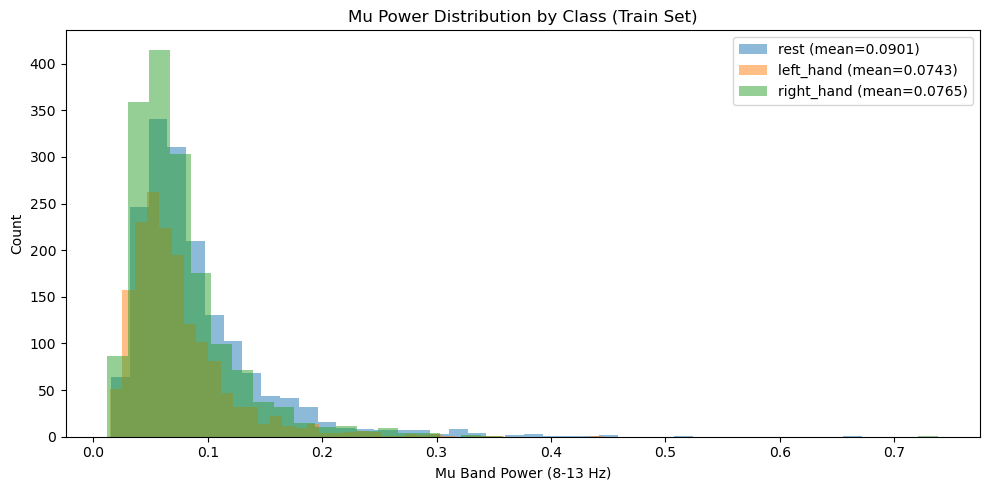

Mu power stats (train):
  rest: mean=0.0901, std=0.0595
  left_hand: mean=0.0743, std=0.0451
  right_hand: mean=0.0765, std=0.0476


In [76]:
from scipy.signal import welch

def compute_mu_power(X, sfreq=160.0, mu_band=(8, 13)):
    """
    Compute average mu-band (8-13 Hz) power for each epoch.
    X: (n_epochs, n_channels, n_timepoints)
    Returns: (n_epochs,) array of mean mu power across channels
    """
    mu_powers = []
    for i in range(X.shape[0]):
        epoch_power = []
        for ch in range(X.shape[1]):
            freqs, psd = welch(X[i, ch], fs=sfreq, nperseg=256)
            mu_mask = (freqs >= mu_band[0]) & (freqs <= mu_band[1])
            epoch_power.append(psd[mu_mask].mean())
        mu_powers.append(np.mean(epoch_power))
    return np.array(mu_powers)


mu_power_train = compute_mu_power(X_train)
mu_power_val = compute_mu_power(X_val)
mu_power_test = compute_mu_power(X_test)

# Visualize mu power distribution per class
fig, ax = plt.subplots(figsize=(10, 5))
for cls, name in enumerate(['rest', 'left_hand', 'right_hand']):
    cls_power = mu_power_train[y_train == cls]
    ax.hist(cls_power, bins=40, alpha=0.5, label=f'{name} (mean={cls_power.mean():.4f})')
ax.set_xlabel('Mu Band Power (8-13 Hz)')
ax.set_ylabel('Count')
ax.set_title('Mu Power Distribution by Class (Train Set)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mu power stats (train):")
for cls, name in enumerate(['rest', 'left_hand', 'right_hand']):
    p = mu_power_train[y_train == cls]
    print(f"  {name}: mean={p.mean():.4f}, std={p.std():.4f}")

Best mu threshold (train): 0.1376, F1: 0.7803
Validation gate F1: 0.7761
Validation gate accuracy (rest vs active): 0.6487


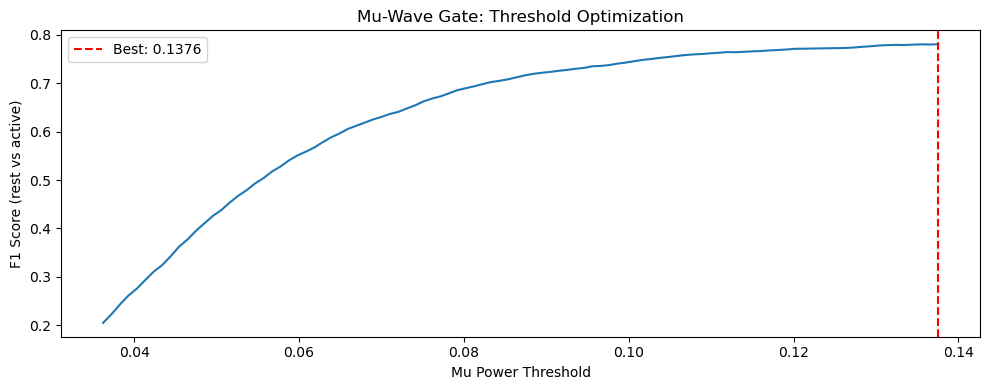

In [77]:
from sklearn.metrics import f1_score

def find_best_mu_threshold(mu_power, y_true, thresholds=None):
    """
    Find the threshold that best separates rest (class 0) from active (class 1,2).
    Binary labels: rest=0, active=1
    """
    y_binary = (y_true > 0).astype(int)  # 0=rest, 1=active

    if thresholds is None:
        thresholds = np.linspace(
            np.percentile(mu_power, 10),
            np.percentile(mu_power, 90),
            100
        )

    best_thresh, best_f1 = 0, 0
    results = []
    for t in thresholds:
        # High mu power → rest (0), low → active (1)
        y_pred = (mu_power < t).astype(int)
        f1 = f1_score(y_binary, y_pred, average='binary')
        results.append({'threshold': t, 'f1': f1})
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = t

    return best_thresh, best_f1, pd.DataFrame(results)


# Find threshold on train, validate on val
best_thresh, train_f1, thresh_df = find_best_mu_threshold(mu_power_train, y_train)
print(f"Best mu threshold (train): {best_thresh:.4f}, F1: {train_f1:.4f}")

# Validate
y_val_binary = (y_val > 0).astype(int)
y_val_gate = (mu_power_val < best_thresh).astype(int)
val_gate_f1 = f1_score(y_val_binary, y_val_gate, average='binary')
print(f"Validation gate F1: {val_gate_f1:.4f}")

# Accuracy of the gating itself
gate_acc = (y_val_gate == y_val_binary).mean()
print(f"Validation gate accuracy (rest vs active): {gate_acc:.4f}")

# Plot threshold curve
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresh_df['threshold'], thresh_df['f1'])
ax.axvline(best_thresh, color='r', linestyle='--', label=f'Best: {best_thresh:.4f}')
ax.set_xlabel('Mu Power Threshold')
ax.set_ylabel('F1 Score (rest vs active)')
ax.set_title('Mu-Wave Gate: Threshold Optimization')
ax.legend()
plt.tight_layout()
plt.show()

### Train binary left vs right EEGNet


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# Filter only left (1) and right (2) epochs for Stage 2
lr_train_mask = y_train > 0  # exclude rest
lr_val_mask = y_val > 0
lr_test_mask = y_test > 0

X_train_lr = X_train[lr_train_mask]
y_train_lr = y_train[lr_train_mask] - 1  # remap: 1→0 (left), 2→1 (right)
X_val_lr = X_val[lr_val_mask]
y_val_lr = y_val[lr_val_mask] - 1
X_test_lr = X_test[lr_test_mask]
y_test_lr = y_test[lr_test_mask] - 1

print(f"Left/Right train: {len(X_train_lr)} (left={sum(y_train_lr==0)}, right={sum(y_train_lr==1)})")
print(f"Left/Right val:   {len(X_val_lr)} (left={sum(y_val_lr==0)}, right={sum(y_val_lr==1)})")
print(f"Left/Right test:  {len(X_test_lr)} (left={sum(y_test_lr==0)}, right={sum(y_test_lr==1)})")

lr_train_loader = DataLoader(EEGDataset(X_train_lr, y_train_lr), batch_size=64, shuffle=True)
lr_val_loader   = DataLoader(EEGDataset(X_val_lr, y_val_lr),     batch_size=64, shuffle=False)
lr_test_loader  = DataLoader(EEGDataset(X_test_lr, y_test_lr),   batch_size=64, shuffle=False)

# Binary EEGNet (2 classes, 21 channels)
lr_model = EEGNet(chans=21, classes=2).to(device)
lr_optimizer = torch.optim.Adam(lr_model.parameters(), lr=0.001)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(lr_optimizer, T_max=100)

# Weighted loss for L/R imbalance 
lr_weights = compute_class_weight('balanced', classes=np.unique(y_train_lr), y=y_train_lr)
lr_loss_fn = nn.CrossEntropyLoss(
    weight=torch.tensor(lr_weights, dtype=torch.float32).to(device)
)
print(f"L/R class weights: {lr_weights}")

lr_results, lr_best_val = train(
    model=lr_model,
    train_dataloader=lr_train_loader,
    val_dataloader=lr_val_loader,
    test_dataloader=lr_test_loader,
    optimizer=lr_optimizer,
    loss_fn=lr_loss_fn,
    scheduler=lr_scheduler,
    device=device,
    epochs=100
)

### Plot L/R training curves


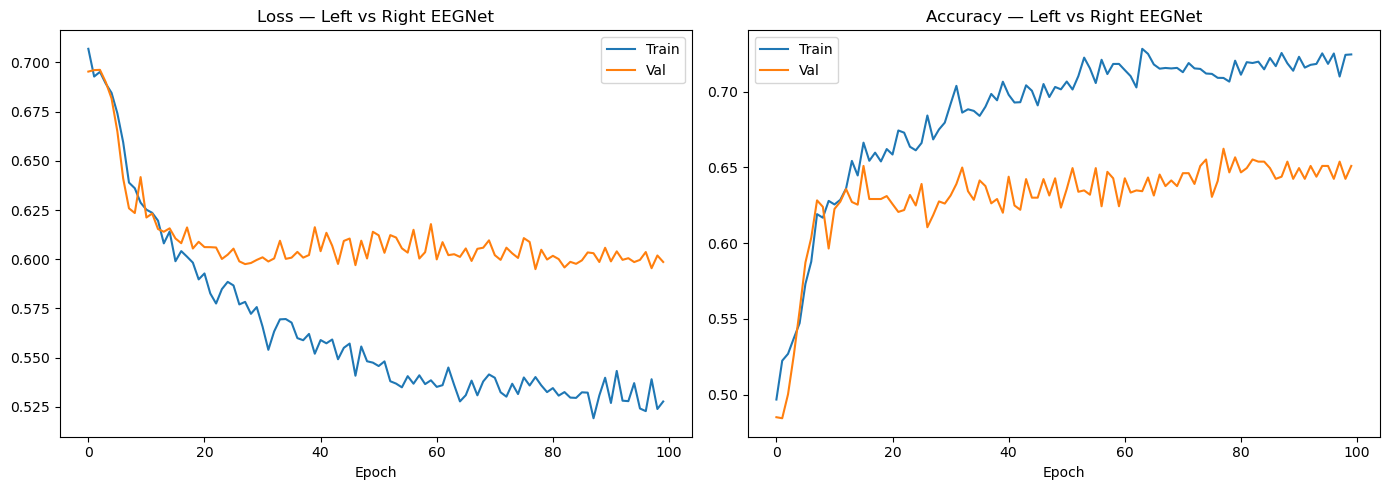

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(lr_results['train_loss'], label='Train')
axes[0].plot(lr_results['val_loss'], label='Val')
axes[0].set_title('Loss — Left vs Right EEGNet')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(lr_results['train_acc'], label='Train')
axes[1].plot(lr_results['val_acc'], label='Val')
axes[1].set_title('Accuracy — Left vs Right EEGNet')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

### Full 2-stage pipeline evaluation on test set


  Two-Stage Pipeline: Mu-Gate + Left/Right EEGNet

Test Accuracy: 0.4283
              precision    recall  f1-score   support

        rest       0.44      0.10      0.16       365
   left_hand       0.42      0.62      0.50       381
  right_hand       0.43      0.55      0.48       370

    accuracy                           0.43      1116
   macro avg       0.43      0.42      0.38      1116
weighted avg       0.43      0.43      0.39      1116



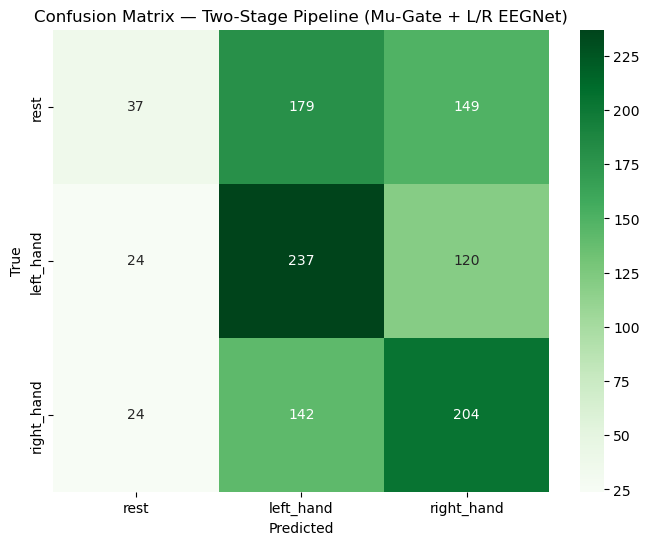

In [81]:
def two_stage_predict(X, mu_power, mu_threshold, lr_model, device):
    """
    Stage 1: Mu-wave gate — high mu power → rest (0)
    Stage 2: Binary EEGNet — classify active epochs as left (1) or right (2)
    """
    predictions = np.zeros(len(X), dtype=int)

    # Stage 1: gate
    active_mask = mu_power < mu_threshold
    rest_mask = ~active_mask
    predictions[rest_mask] = 0  # rest

    # Stage 2: classify active epochs
    if active_mask.sum() > 0:
        X_active = X[active_mask]
        active_ds = DataLoader(
            EEGDataset(X_active, np.zeros(len(X_active))),  # dummy labels
            batch_size=64, shuffle=False
        )

        lr_model.eval()
        active_preds = []
        with torch.inference_mode():
            for X_batch, _ in active_ds:
                logits = lr_model(X_batch.to(device))
                preds = logits.argmax(dim=1).cpu().numpy()
                active_preds.extend(preds)

        # Remap back: 0→1 (left), 1→2 (right)
        active_preds = np.array(active_preds) + 1
        predictions[active_mask] = active_preds

    return predictions


# Run 2-stage pipeline on test set
y_pred_2stage = two_stage_predict(X_test, mu_power_test, best_thresh, lr_model, device)

print("="*60)
print("  Two-Stage Pipeline: Mu-Gate + Left/Right EEGNet")
print("="*60)
print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred_2stage):.4f}")
print(classification_report(y_test, y_pred_2stage,
                            target_names=['rest', 'left_hand', 'right_hand']))

cm = confusion_matrix(y_test, y_pred_2stage)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['rest', 'left_hand', 'right_hand'],
            yticklabels=['rest', 'left_hand', 'right_hand'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix — Two-Stage Pipeline (Mu-Gate + L/R EEGNet)')
plt.show()

### Compare all approaches



  Final Comparison — All Approaches on Test Set
  EEGNet 3-class (21ch)         : 0.6129
  2-Stage Mu+EEGNet             : 0.4283


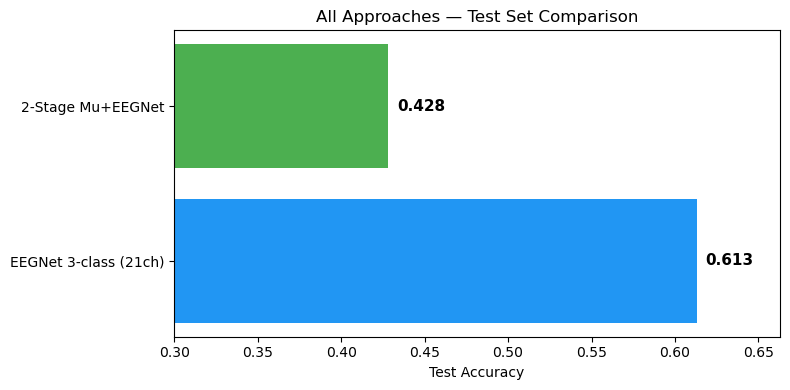

In [83]:
comparison = {
    'EEGNet 3-class (21ch)': accuracy_score(all_labels, all_preds),
    # 'Best ML CSP (21ch)': accuracy_score(y_test, best_ml.predict(X_test)),
    '2-Stage Mu+EEGNet': accuracy_score(y_test, y_pred_2stage),
}

print("\n" + "="*60)
print("  Final Comparison — All Approaches on Test Set")
print("="*60)
for name, acc in sorted(comparison.items(), key=lambda x: x[1], reverse=True):
    print(f"  {name:30s}: {acc:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
names = list(comparison.keys())
accs = list(comparison.values())
colors = ['#2196F3', '#4CAF50', '#FF9800']
bars = ax.barh(names, accs, color=colors)
ax.set_xlabel('Test Accuracy')
ax.set_title('All Approaches — Test Set Comparison')
ax.set_xlim(0.3, max(accs) + 0.05)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{acc:.3f}', va='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

---

# 17. Binary Classification — Left Hand vs Right Hand (no rest)

We repeat the full pipeline but **exclude rest epochs entirely** at the data loading stage.
This is a cleaner MI classification problem — the model only needs to distinguish
between two motor imagery states without the confound of rest.

Uses 21 motor cortex channels, same preprocessing as Section 15.


### 17.1 Epoching — Left & Right only (no rest)


In [108]:
motor_channels = [
    'Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.',
    'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..',
    'Cp5.', 'Cp3.', 'Cp1.', 'Cpz.', 'Cp2.', 'Cp4.', 'Cp6.',
]

# Only left and right — no rest
event_id_binary = {'left_hand': 2, 'right_hand': 3}

all_X = []
all_y = []
all_subjects = []
skipped = []

for subject in tqdm(raw_data, desc="Epoching subjects (L/R only)"):
    try:
        raw = raw_data[subject].copy()
        raw.pick(motor_channels)
        raw.filter(7., 30., fir_design='firwin', skip_by_annotation='edge', verbose=False)

        events, _ = mne.events_from_annotations(raw, event_id='auto', verbose=False)

        epochs = mne.Epochs(raw, events, event_id_binary, tmin=0.0, tmax=4.0,
                            baseline=None, preload=True, verbose=False)

        X = epochs.get_data().astype(np.float32)  # (n_epochs, 21, 641)
        y = epochs.events[:, -1]                   # 2=left, 3=right
        y = y - 2                                  # remap: 0=left, 1=right

        # Per-subject normalization
        for ch in range(X.shape[1]):
            mean = X[:, ch, :].mean()
            std = X[:, ch, :].std()
            if std > 0:
                X[:, ch, :] = (X[:, ch, :] - mean) / std

        all_X.append(X)
        all_y.append(y)
        all_subjects.append(np.full(len(y), int(subject)))

    except Exception as e:
        skipped.append(subject)
        print(f"⚠️ Subject {subject} failed: {e}")

X_all = np.concatenate(all_X, axis=0)
y_all = np.concatenate(all_y, axis=0)
subjects_all = np.concatenate(all_subjects, axis=0)

# Balance classes
print(f"Before balancing: {np.bincount(y_all)}")
min_count = min(np.bincount(y_all))
balanced_idx = []
for cls in range(2):
    cls_idx = np.where(y_all == cls)[0]
    chosen = np.random.choice(cls_idx, size=min_count, replace=False)
    balanced_idx.append(chosen)
balanced_idx = np.concatenate(balanced_idx)
np.random.shuffle(balanced_idx)

X_all = X_all[balanced_idx]
y_all = y_all[balanced_idx]
subjects_all = subjects_all[balanced_idx]

print(f"\nTotal epochs: {X_all.shape[0]}")
print(f"Shape: {X_all.shape}")
print(f"Class distribution (after balancing): {np.bincount(y_all)}  [0=left, 1=right]")
print(f"Unique subjects: {len(np.unique(subjects_all))}")
if skipped:
    print(f"Skipped subjects: {skipped}")


Epoching subjects (L/R only): 100%|██████████| 106/106 [00:02<00:00, 41.19it/s]


Before balancing: [2396 2352]

Total epochs: 4704
Shape: (4704, 21, 641)
Class distribution (after balancing): [2352 2352]  [0=left, 1=right]
Unique subjects: 106


### 17.2 Subject-based split


In [109]:
unique_subjects = np.unique(subjects_all)
np.random.shuffle(unique_subjects)

n = len(unique_subjects)
n_train = int(n * 0.7)
n_val = int(n * 0.15)

train_subjects = set(unique_subjects[:n_train])
val_subjects   = set(unique_subjects[n_train:n_train + n_val])
test_subjects  = set(unique_subjects[n_train + n_val:])

train_mask = np.isin(subjects_all, list(train_subjects))
val_mask   = np.isin(subjects_all, list(val_subjects))
test_mask  = np.isin(subjects_all, list(test_subjects))

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_val,   y_val   = X_all[val_mask],   y_all[val_mask]
X_test,  y_test  = X_all[test_mask],  y_all[test_mask]

print(f"Train: {len(X_train)} epochs from {len(train_subjects)} subjects")
print(f"Val:   {len(X_val)} epochs from {len(val_subjects)} subjects")
print(f"Test:  {len(X_test)} epochs from {len(test_subjects)} subjects")
print(f"\nTrain class dist: {np.bincount(y_train)}  [0=left, 1=right]")
print(f"Val class dist:   {np.bincount(y_val)}")
print(f"Test class dist:  {np.bincount(y_test)}")


Train: 3284 epochs from 74 subjects
Val:   665 epochs from 15 subjects
Test:  755 epochs from 17 subjects

Train class dist: [1644 1640]  [0=left, 1=right]
Val class dist:   [332 333]
Test class dist:  [376 379]


### 17.3 DataLoaders


In [110]:
BATCH_SIZE = 64

train_dataset = EEGDataset(X_train, y_train)
val_dataset   = EEGDataset(X_val, y_val)
test_dataset  = EEGDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")


Train batches: 52, Val batches: 11, Test batches: 12


### 17.4 EEGNet single run — binary L/R (21ch)


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights_bin = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_bin_tensor = torch.tensor(class_weights_bin, dtype=torch.float32).to(device)
print(f"Class weights (binary L/R): {class_weights_bin}")

eeg_net = EEGNet(chans=21, classes=2).to(device)

loss_fn = nn.CrossEntropyLoss(weight=class_weights_bin_tensor)
optimizer = torch.optim.Adam(eeg_net.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

results, best_val = train(
    model=eeg_net,
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    test_dataloader=test_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    scheduler=scheduler,
    device=device,
    epochs=100
)


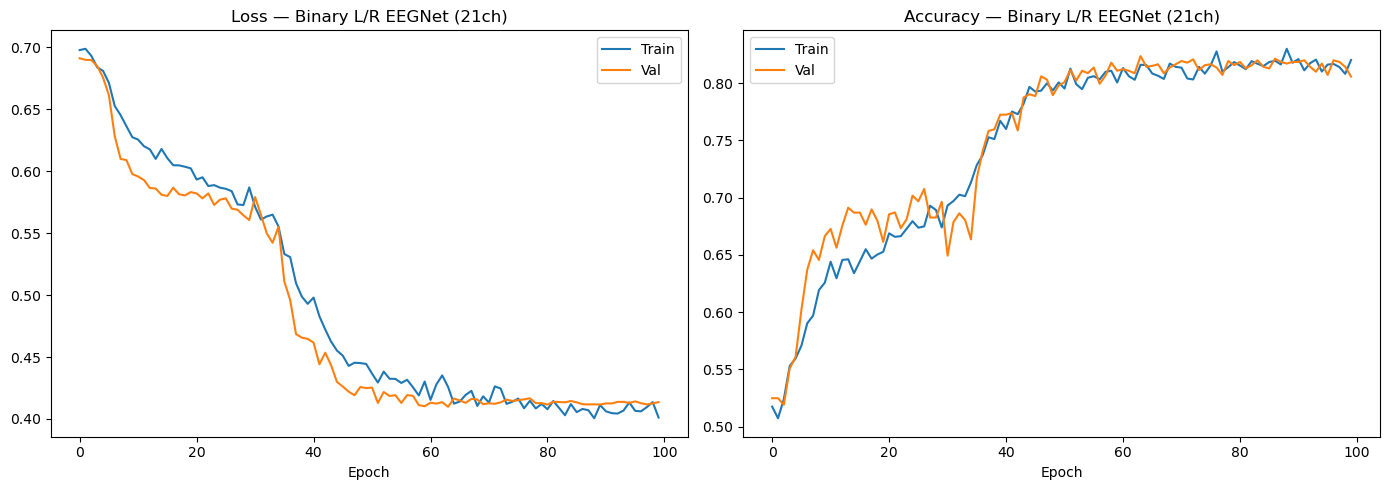

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(results['train_loss'], label='Train')
axes[0].plot(results['val_loss'], label='Val')
axes[0].set_title('Loss — Binary L/R EEGNet (21ch)')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(results['train_acc'], label='Train')
axes[1].plot(results['val_acc'], label='Val')
axes[1].set_title('Accuracy — Binary L/R EEGNet (21ch)')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()


Test loss: 0.4422 | Test acc: 0.7994
              precision    recall  f1-score   support

   left_hand       0.77      0.85      0.81       376
  right_hand       0.83      0.75      0.79       379

    accuracy                           0.80       755
   macro avg       0.80      0.80      0.80       755
weighted avg       0.80      0.80      0.80       755



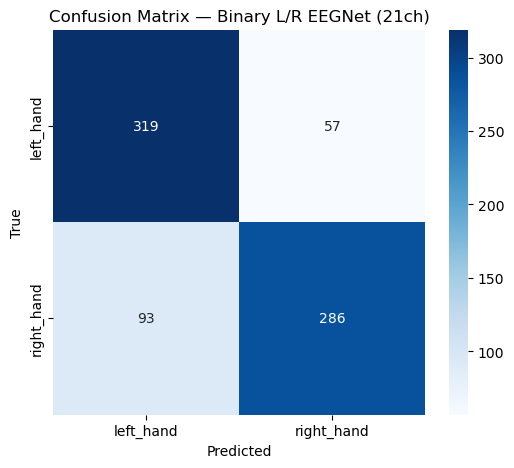

In [113]:
test_loss, test_acc = eval_step(eeg_net, test_loader, loss_fn, device)
print(f"Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")

eeg_net.eval()
all_preds, all_labels = [], []
with torch.inference_mode():
    for X_batch, y_batch in test_loader:
        preds = eeg_net(X_batch.to(device)).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

print(classification_report(all_labels, all_preds,
                            target_names=['left_hand', 'right_hand']))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['left_hand', 'right_hand'],
            yticklabels=['left_hand', 'right_hand'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix — Binary L/R EEGNet (21ch)')
plt.show()


In [114]:
cv_mask = train_mask | val_mask

fold_results, mean_acc, std_acc = cross_validate_subjects(
    X_all[cv_mask], y_all[cv_mask], subjects_all[cv_mask],
    n_splits=5, epochs=50, lr=0.001,
    f1=8, f2=16, d=2, chans=21, classes=2,
)



Fold 1/5
Train: 3192 epochs, Val: 757 epochs
Train subjects: 72, Val subjects: 17
Fold 1 class weights: [0.99937383 1.00062696]
Fold 1 best val_acc: 0.7246

Fold 2/5
Train: 3151 epochs, Val: 798 epochs
Train subjects: 71, Val subjects: 18
Fold 2 class weights: [0.99652119 1.00350318]
Fold 2 best val_acc: 0.6978

Fold 3/5
Train: 3151 epochs, Val: 798 epochs
Train subjects: 71, Val subjects: 18
Fold 3 class weights: [1.00031746 0.99968274]
Fold 3 best val_acc: 0.6829

Fold 4/5
Train: 3151 epochs, Val: 798 epochs
Train subjects: 71, Val subjects: 18
Fold 4 class weights: [0.99526216 1.00478316]
Fold 4 best val_acc: 0.6739

Fold 5/5
Train: 3151 epochs, Val: 798 epochs
Train subjects: 71, Val subjects: 18
Fold 5 class weights: [1.00478316 0.99526216]
Fold 5 best val_acc: 0.7707

Cross-validation results (5 folds):
Fold accuracies: ['0.7246', '0.6978', '0.6829', '0.6739', '0.7707']
Mean: 0.7100 ± 0.0349


In [115]:
### 17.8 EEGNet grid search (binary L/R)

In [ ]:
param_grid = {
    'lr':           [0.005, 0.001, 0.0005],
    'dropout_rate': [0.25, 0.5],
    'f1':           [8, 16],
    'd':            [2, 4],
}

keys = list(param_grid.keys())
combos = list(itertools.product(*param_grid.values()))
print(f"Total combinations: {len(combos)}")

grid_results = []
for i, combo in enumerate(combos):
    params = dict(zip(keys, combo))
    f2 = params['f1'] * params['d']

    print(f"\n{'#'*60}")
    print(f"Combo {i+1}/{len(combos)}: {params}, f2={f2}")

    _, mean_acc, std_acc = cross_validate_subjects(
        X_all[cv_mask], y_all[cv_mask], subjects_all[cv_mask],
        n_splits=3, epochs=30,
        lr=params['lr'], dropout_rate=params['dropout_rate'],
        f1=params['f1'], f2=f2, d=params['d'],
        chans=21, classes=2
    )
    grid_results.append({**params, 'f2': f2, 'mean_acc': mean_acc, 'std_acc': std_acc})

grid_df = pd.DataFrame(grid_results).sort_values('mean_acc', ascending=False)
print("\nBinary L/R EEGNet Grid Search Results:")
print(grid_df.to_string(index=False))


### 17.9 Final EEGNet with best params


In [ ]:
best_params = grid_df.iloc[0].to_dict()
print(f"Best: {best_params}")

final_model = EEGNet(
    chans=21, classes=2,
    f1=int(best_params['f1']), f2=int(best_params['f2']),
    d=int(best_params['d']), dropout_rate=best_params['dropout_rate'],
).to(device)

final_train_dl = DataLoader(EEGDataset(X_all[cv_mask], y_all[cv_mask]),
                            batch_size=64, shuffle=True)
final_optimizer = torch.optim.Adam(final_model.parameters(), lr=best_params['lr'])
final_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(final_optimizer, T_max=50)

final_loss_fn = nn.CrossEntropyLoss(
    weight=torch.tensor(
        compute_class_weight('balanced', classes=np.unique(y_all[cv_mask]), y=y_all[cv_mask]),
        dtype=torch.float32
    ).to(device)
)

final_results, _ = train(
    model=final_model,
    train_dataloader=final_train_dl,
    val_dataloader=test_loader, test_dataloader=test_loader,
    optimizer=final_optimizer, loss_fn=final_loss_fn,
    scheduler=final_scheduler, device=device, epochs=50
)


### 17.10 Final test evaluation + confusion matrix


              precision    recall  f1-score   support

   left_hand       0.77      0.83      0.80       376
  right_hand       0.81      0.75      0.78       379

    accuracy                           0.79       755
   macro avg       0.79      0.79      0.79       755
weighted avg       0.79      0.79      0.79       755



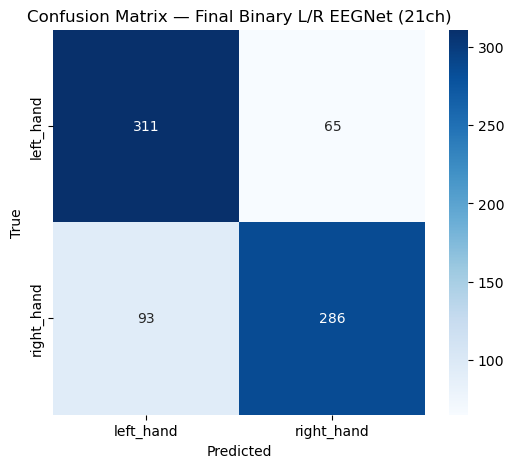

In [118]:
final_model.eval()
all_preds, all_labels = [], []
with torch.inference_mode():
    for X_batch, y_batch in test_loader:
        preds = final_model(X_batch.to(device)).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

print(classification_report(all_labels, all_preds,
                            target_names=['left_hand', 'right_hand']))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['left_hand', 'right_hand'],
            yticklabels=['left_hand', 'right_hand'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix — Final Binary L/R EEGNet (21ch)')
plt.show()


### 17.11 CSP + LDA baseline (binary L/R)


In [119]:
from mne.decoding import CSP

csp = CSP(n_components=6, reg='ledoit_wolf', log=True, norm_trace=False)
lda = LinearDiscriminantAnalysis()

pipe = Pipeline([
    ('csp', csp),
    ('classifier', lda)
])

cv_mask_arr = train_mask | val_mask
X_cv = X_all[cv_mask_arr]
y_cv = y_all[cv_mask_arr]
subjects_cv = subjects_all[cv_mask_arr]

gkf = GroupKFold(n_splits=5)
scores = cross_val_score(pipe, X_cv, y_cv,
                         cv=gkf, groups=subjects_cv, scoring='accuracy')
print(f"CSP+LDA binary L/R: {scores.mean():.4f} ± {scores.std():.4f}")


Computing rank from data with rank=None
    Using tolerance 27 (2.2e-16 eps * 21 dim * 5.8e+15  max singular value)
    Estimated rank (data): 21
    data: rank 21 computed from 21 data channels with 0 projectors
Reducing data rank from 21 -> 21
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 27 (2.2e-16 eps * 21 dim * 5.7e+15  max singular value)
    Estimated rank (data): 21
    data: rank 21 computed from 21 data channels with 0 projectors
Reducing data rank from 21 -> 21
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 27 (2.2e-16 eps * 21 dim * 5.7e+15  max singular value)
    Estimated rank (data): 21
    data: rank 21 computed from 21 data channels with 0 projectors
Reducing data rank from 21 -> 21
Estimating class=0 covariance using LEDOIT_WOL

### 17.12 ML grid search — CSP + classifiers (binary L/R)


In [ ]:
# For binary, CSP works directly (no need for MultiClassCSP / pairwise)
models = {
    'LDA': {
        'model': LinearDiscriminantAnalysis(),
        'params': [
            {
                'classifier__solver': ['svd'],
                'classifier__shrinkage': [None],
                'csp__n_components': [4, 6, 8],
            },
            {
                'classifier__solver': ['lsqr'],
                'classifier__shrinkage': [None, 'auto'],
                'csp__n_components': [4, 6, 8],
            },
        ]
    },
    'SVM': {
        'model': SVC(probability=True, random_state=42, class_weight='balanced'),
        'params': {
            'classifier__C': [0.1, 1.0, 10.0],
            'classifier__kernel': ['rbf', 'linear'],
            'classifier__gamma': ['scale', 'auto'],
            'csp__n_components': [4, 6, 8],
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(random_state=42, class_weight='balanced'),
        'params': {
            'classifier__n_estimators': [100, 200],
            'classifier__max_depth': [5, 10, None],
            'classifier__min_samples_leaf': [1, 5],
            'csp__n_components': [4, 6, 8],
        }
    },
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {
            'classifier__n_neighbors': [3, 5, 7, 11],
            'classifier__weights': ['uniform', 'distance'],
            'classifier__metric': ['euclidean', 'manhattan'],
            'csp__n_components': [4, 6, 8],
        }
    },
    'GradientBoosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {
            'classifier__n_estimators': [100, 200],
            'classifier__learning_rate': [0.01, 0.1],
            'classifier__max_depth': [3, 5],
            'csp__n_components': [4, 6, 8],
        }
    },
    'LogisticRegression': {
        'model': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
        'params': {
            'classifier__C': [0.01, 0.1, 1.0, 10.0],
            'classifier__penalty': ['l1', 'l2'],
            'classifier__solver': ['saga'],
            'csp__n_components': [4, 6, 8],
        }
    },
    'MLP': {
        'model': MLPClassifier(max_iter=500, random_state=42, early_stopping=True),
        'params': {
            'classifier__hidden_layer_sizes': [(64,), (128,), (64, 32)],
            'classifier__alpha': [0.0001, 0.001],
            'classifier__learning_rate_init': [0.001, 0.01],
            'csp__n_components': [4, 6, 8],
        }
    },
}

print(f"Models to evaluate: {list(models.keys())}")

all_results = []
for name, config in models.items():
    print(f"\n{'#'*60}")
    print(f"  {name}")
    print(f"{'#'*60}")

    # Binary CSP — no pairwise wrapper needed
    pipe = Pipeline([
        ('csp', CSP(n_components=4, reg='ledoit_wolf', log=True, norm_trace=False)),
        ('scaler', StandardScaler()),
        ('classifier', config['model']),
    ])

    grid = GridSearchCV(
        pipe, param_grid=config['params'],
        cv=gkf, scoring='accuracy', n_jobs=-1, verbose=0, error_score='raise',
    )

    start = time.time()
    grid.fit(X_cv, y_cv, groups=subjects_cv)
    elapsed = time.time() - start

    print(f"Best params: {grid.best_params_}")
    print(f"Best CV accuracy: {grid.best_score_:.4f}")
    print(f"Time: {elapsed:.1f}s")

    all_results.append({
        'model': name,
        'best_cv_acc': grid.best_score_,
        'best_params': grid.best_params_,
        'time_s': elapsed,
        'grid_obj': grid,
    })


### 17.13 ML comparison chart


             Model  CV Accuracy   Time (s)
               MLP     0.615959 147.363913
               SVM     0.614123 152.171857
LogisticRegression     0.611197  98.783168
               LDA     0.608874  39.991779
      RandomForest     0.606259 148.609996
  GradientBoosting     0.600040 101.922921
               KNN     0.585537 195.537279


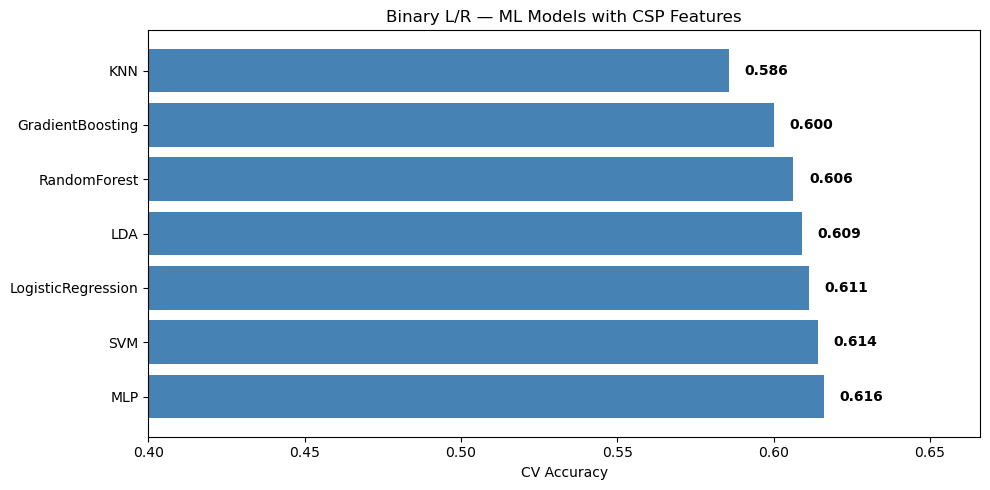

In [121]:
results_df = pd.DataFrame([
    {'Model': r['model'], 'CV Accuracy': r['best_cv_acc'], 'Time (s)': r['time_s']}
    for r in all_results
]).sort_values('CV Accuracy', ascending=False)

print(results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(results_df['Model'], results_df['CV Accuracy'], color='steelblue')
ax.set_xlabel('CV Accuracy')
ax.set_title('Binary L/R — ML Models with CSP Features')
ax.set_xlim(0.4, max(results_df['CV Accuracy']) + 0.05)
for i, (acc, name) in enumerate(zip(results_df['CV Accuracy'], results_df['Model'])):
    ax.text(acc + 0.005, i, f'{acc:.3f}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()


### 17.14 Best ML model on test set


Best model: MLP
Best CV accuracy: 0.6160

Test Accuracy: 0.5894
              precision    recall  f1-score   support

   left_hand       0.58      0.64      0.61       376
  right_hand       0.60      0.54      0.57       379

    accuracy                           0.59       755
   macro avg       0.59      0.59      0.59       755
weighted avg       0.59      0.59      0.59       755



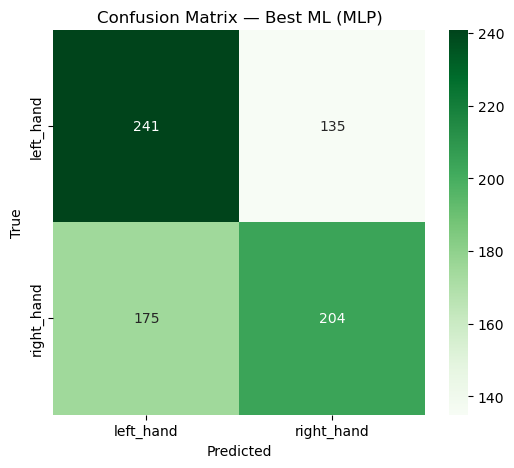

In [122]:
best_result = max(all_results, key=lambda x: x['best_cv_acc'])
best_ml = best_result['grid_obj'].best_estimator_

print(f"Best model: {best_result['model']}")
print(f"Best CV accuracy: {best_result['best_cv_acc']:.4f}")

y_pred = best_ml.predict(X_test)
print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred,
                            target_names=['left_hand', 'right_hand']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['left_hand', 'right_hand'],
            yticklabels=['left_hand', 'right_hand'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix — Best ML ({best_result["model"]})')
plt.show()


### 17.15 Compare all binary L/R approaches



  Binary L/R — All Approaches on Test Set
  EEGNet binary L/R (21ch)                : 0.7907
  Best ML CSP (MLP)                       : 0.5894


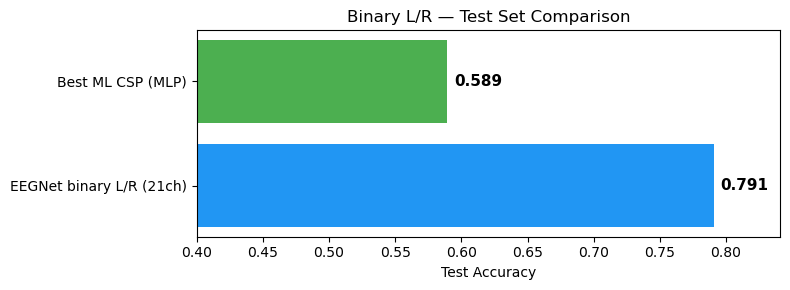

In [124]:
comparison = {
    'EEGNet binary L/R (21ch)': accuracy_score(all_labels, all_preds),
    f'Best ML CSP ({best_result["model"]})': accuracy_score(y_test, best_ml.predict(X_test)),
}

print("\n" + "="*60)
print("  Binary L/R — All Approaches on Test Set")
print("="*60)
for name, acc in sorted(comparison.items(), key=lambda x: x[1], reverse=True):
    print(f"  {name:40s}: {acc:.4f}")

fig, ax = plt.subplots(figsize=(8, 3))
names = list(comparison.keys())
accs = list(comparison.values())
colors = ['#2196F3', '#4CAF50']
bars = ax.barh(names, accs, color=colors)
ax.set_xlabel('Test Accuracy')
ax.set_title('Binary L/R — Test Set Comparison')
ax.set_xlim(0.4, max(accs) + 0.05)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{acc:.3f}', va='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


---

# 18. Preprocessing Grid Search

We search over preprocessing hyperparameters that were fixed until now:

- **Bandpass filter range** (low_freq, high_freq)
- **Epoch time window** (tmin, tmax)
- **Baseline correction** (None vs pre-stimulus)

Each combo requires re-epoching the raw data from scratch, so we use a lightweight
3-fold CV with 30 epochs to keep runtime manageable.

This runs on binary L/R (no rest), 21 motor cortex channels — building on Section 17.


### 18.1 Parameterized epoching function


In [125]:
motor_channels = [
    'Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.',
    'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..',
    'Cp5.', 'Cp3.', 'Cp1.', 'Cpz.', 'Cp2.', 'Cp4.', 'Cp6.',
]

event_id_binary = {'left_hand': 2, 'right_hand': 3}


def epoch_with_params(raw_data, low_freq, high_freq, tmin, tmax, baseline):
    """
    Re-epoch all subjects with given preprocessing parameters.
    Returns balanced X_all, y_all, subjects_all.
    """
    all_X, all_y, all_subjects = [], [], []
    skipped = []

    for subject in raw_data:
        try:
            raw = raw_data[subject].copy()
            raw.pick(motor_channels)
            raw.filter(low_freq, high_freq, fir_design='firwin',
                       skip_by_annotation='edge', verbose=False)

            events, _ = mne.events_from_annotations(raw, event_id='auto', verbose=False)

            epochs = mne.Epochs(raw, events, event_id_binary,
                                tmin=tmin, tmax=tmax,
                                baseline=baseline,
                                preload=True, verbose=False)

            X = epochs.get_data().astype(np.float32)
            y = epochs.events[:, -1] - 2  # 0=left, 1=right

            # Per-subject normalization
            for ch in range(X.shape[1]):
                mean = X[:, ch, :].mean()
                std = X[:, ch, :].std()
                if std > 0:
                    X[:, ch, :] = (X[:, ch, :] - mean) / std

            all_X.append(X)
            all_y.append(y)
            all_subjects.append(np.full(len(y), int(subject)))

        except Exception as e:
            skipped.append(subject)

    X_all = np.concatenate(all_X, axis=0)
    y_all = np.concatenate(all_y, axis=0)
    subjects_all = np.concatenate(all_subjects, axis=0)

    min_count = min(np.bincount(y_all))
    balanced_idx = []
    for cls in range(2):
        cls_idx = np.where(y_all == cls)[0]
        chosen = np.random.choice(cls_idx, size=min_count, replace=False)
        balanced_idx.append(chosen)
    balanced_idx = np.concatenate(balanced_idx)
    np.random.shuffle(balanced_idx)

    return X_all[balanced_idx], y_all[balanced_idx], subjects_all[balanced_idx]


# Quick test
X_test_ep, y_test_ep, s_test_ep = epoch_with_params(
    raw_data, low_freq=7., high_freq=30., tmin=0.0, tmax=4.0, baseline=None
)
print(f"Test: {X_test_ep.shape}, classes: {np.bincount(y_test_ep)}, "
      f"time_points: {X_test_ep.shape[2]}")


Test: (4704, 21, 641), classes: [2352 2352], time_points: 641


### 18.2 Lightweight CV for preprocessing search

Since each combo requires re-epoching (expensive), we use 3-fold CV with 30 epochs.
The EEGNet `time_points` parameter must match the actual number of timepoints
produced by each tmin/tmax combo.


In [126]:
from sklearn.utils.class_weight import compute_class_weight


def cv_for_preprocessing(X, y, subjects, n_splits=3, epochs=30,
                         lr=0.001, chans=21, classes=2):
    """
    Quick subject-based CV that adapts to varying time_points.
    Returns mean_acc, std_acc.
    """
    time_points = X.shape[2]
    gkf = GroupKFold(n_splits=n_splits)
    fold_accs = []

    for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=subjects)):
        X_tr, y_tr = X[train_idx], y[train_idx]
        X_vl, y_vl = X[val_idx], y[val_idx]

        train_dl = DataLoader(EEGDataset(X_tr, y_tr), batch_size=64, shuffle=True)
        val_dl   = DataLoader(EEGDataset(X_vl, y_vl), batch_size=64, shuffle=False)

        model = EEGNet(chans=chans, classes=classes,
                       time_points=time_points).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        weights = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
        loss_fn = nn.CrossEntropyLoss(
            weight=torch.tensor(weights, dtype=torch.float32).to(device)
        )

        best_val_acc = 0.0
        for epoch in range(epochs):
            train_step(model, train_dl, loss_fn, optimizer, device)
            _, val_acc = eval_step(model, val_dl, loss_fn, device)
            if val_acc > best_val_acc:
                best_val_acc = val_acc

        fold_accs.append(best_val_acc)

    return np.mean(fold_accs), np.std(fold_accs)

print("cv_for_preprocessing ready")


cv_for_preprocessing ready


### 18.3 Define preprocessing grid


In [127]:
preprocessing_grid = {
    'bandpass': [
        (8, 12),     # mu only
        (13, 30),    # beta only
        (8, 30),     # mu + beta
        (7, 30),     # current (baseline)
        (4, 40),     # wide
    ],
    'time_window': [
        (0.0, 4.0),  # current (baseline)
        (0.5, 3.5),  # trimmed
        (0.5, 2.5),  # early MI window
        (1.0, 3.0),  # peak ERD window
    ],
    'baseline': [
        None,           # no baseline (current)
        (None, 0),      # pre-stimulus baseline correction
    ],
}

total_combos = (len(preprocessing_grid['bandpass'])
                * len(preprocessing_grid['time_window'])
                * len(preprocessing_grid['baseline']))
print(f"Total preprocessing combinations: {total_combos}")
print(f"Each runs 3-fold CV × 30 epochs")
print(f"\nBandpass options: {preprocessing_grid['bandpass']}")
print(f"Time windows: {preprocessing_grid['time_window']}")
print(f"Baseline: {preprocessing_grid['baseline']}")


Total preprocessing combinations: 40
Each runs 3-fold CV × 30 epochs

Bandpass options: [(8, 12), (13, 30), (8, 30), (7, 30), (4, 40)]
Time windows: [(0.0, 4.0), (0.5, 3.5), (0.5, 2.5), (1.0, 3.0)]
Baseline: [None, (None, 0)]


### 18.4 Run preprocessing grid search


In [128]:
import time

preproc_results = []
combo_num = 0

for low_freq, high_freq in preprocessing_grid['bandpass']:
    for tmin, tmax in preprocessing_grid['time_window']:
        for baseline in preprocessing_grid['baseline']:
            combo_num += 1

            # baseline=(None, 0) needs tmin < 0 to have pre-stimulus data
            actual_tmin = tmin
            if baseline == (None, 0) and tmin >= 0:
                actual_tmin = -0.5  # add 0.5s pre-stimulus for baseline

            label = (f"bp={low_freq}-{high_freq}Hz, "
                     f"t={actual_tmin}-{tmax}s, "
                     f"bl={'yes' if baseline else 'no'}")
            print(f"\n{'#'*60}")
            print(f"  Combo {combo_num}/{total_combos}: {label}")
            print(f"{'#'*60}")

            start = time.time()

            try:
                # Re-epoch with these params
                X, y, subjects = epoch_with_params(
                    raw_data, low_freq, high_freq,
                    actual_tmin, tmax, baseline
                )

                # Use all data for CV (no held-out test — this is just for param selection)
                mean_acc, std_acc = cv_for_preprocessing(X, y, subjects)

                elapsed = time.time() - start
                print(f"  → Accuracy: {mean_acc:.4f} ± {std_acc:.4f} ({elapsed:.0f}s)")
                print(f"  → Shape: {X.shape} (time_points={X.shape[2]})")

                preproc_results.append({
                    'low_freq': low_freq,
                    'high_freq': high_freq,
                    'tmin': actual_tmin,
                    'tmax': tmax,
                    'baseline': 'yes' if baseline else 'no',
                    'time_points': X.shape[2],
                    'n_epochs': X.shape[0],
                    'mean_acc': mean_acc,
                    'std_acc': std_acc,
                    'time_s': elapsed,
                })

            except Exception as e:
                print(f"  ✗ FAILED: {e}")
                preproc_results.append({
                    'low_freq': low_freq,
                    'high_freq': high_freq,
                    'tmin': actual_tmin,
                    'tmax': tmax,
                    'baseline': 'yes' if baseline else 'no',
                    'time_points': None,
                    'n_epochs': None,
                    'mean_acc': None,
                    'std_acc': None,
                    'time_s': time.time() - start,
                })



############################################################
  Combo 1/40: bp=8-12Hz, t=0.0-4.0s, bl=no
############################################################
  → Accuracy: 0.6536 ± 0.0281 (21s)
  → Shape: (4704, 21, 641) (time_points=641)

############################################################
  Combo 2/40: bp=8-12Hz, t=-0.5-4.0s, bl=yes
############################################################
  → Accuracy: 0.6566 ± 0.0160 (24s)
  → Shape: (4704, 21, 721) (time_points=721)

############################################################
  Combo 3/40: bp=8-12Hz, t=0.5-3.5s, bl=no
############################################################
  → Accuracy: 0.6384 ± 0.0071 (17s)
  → Shape: (4724, 21, 481) (time_points=481)

############################################################
  Combo 4/40: bp=8-12Hz, t=-0.5-3.5s, bl=yes
############################################################
  → Accuracy: 0.6463 ± 0.0266 (21s)
  → Shape: (4724, 21, 641) (time_points=641)

#######

### 18.5 Results


In [129]:
preproc_df = pd.DataFrame(preproc_results)
preproc_df = preproc_df.dropna(subset=['mean_acc'])
preproc_df = preproc_df.sort_values('mean_acc', ascending=False)

print("Preprocessing Grid Search Results (sorted by accuracy):")
print("="*90)
print(preproc_df.to_string(index=False))

print(f"\n{'='*90}")
print(f"Best combo:")
best = preproc_df.iloc[0]
print(f"  Bandpass: {best['low_freq']}-{best['high_freq']} Hz")
print(f"  Window:   {best['tmin']} to {best['tmax']}s")
print(f"  Baseline: {best['baseline']}")
print(f"  Accuracy: {best['mean_acc']:.4f} ± {best['std_acc']:.4f}")


Preprocessing Grid Search Results (sorted by accuracy):
 low_freq  high_freq  tmin  tmax baseline  time_points  n_epochs  mean_acc  std_acc    time_s
        4         40  -0.5   3.5      yes          641      4724  0.693417 0.018819 21.416433
        4         40   0.0   4.0       no          641      4704  0.687861 0.020008 21.263920
        4         40  -0.5   2.5      yes          481      4724  0.684262 0.015822 17.619218
        4         40  -0.5   3.0      yes          561      4724  0.676934 0.007784 19.632452
        7         30  -0.5   3.0      yes          561      4724  0.676515 0.007583 19.811553
        4         40  -0.5   4.0      yes          721      4704  0.672710 0.017356 23.560167
       13         30   0.0   4.0       no          641      4704  0.669632 0.039588 21.774787
        7         30  -0.5   3.5      yes          641      4724  0.669297 0.020097 21.417161
        4         40   0.5   3.5       no          481      4724  0.668355 0.021701 17.412089
    

### 18.6 Visualize results


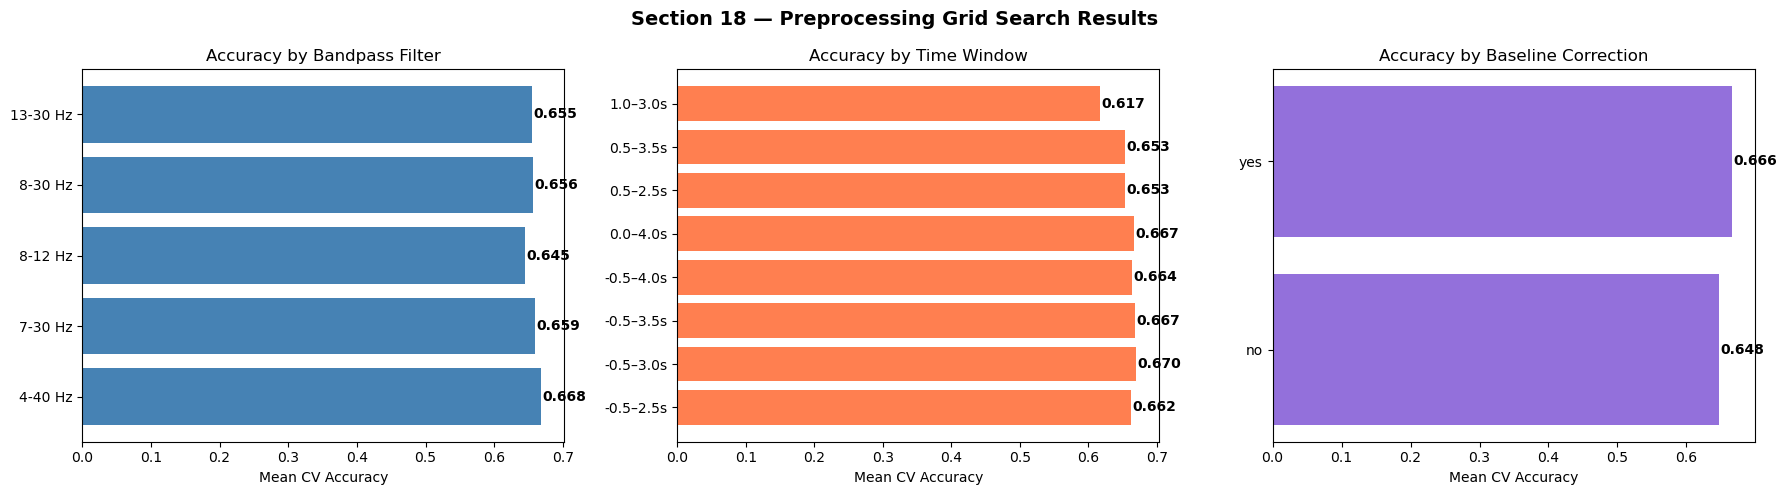

In [130]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

bp_groups = preproc_df.groupby(['low_freq', 'high_freq'])['mean_acc'].mean()
bp_labels = [f"{int(l)}-{int(h)} Hz" for l, h in bp_groups.index]
axes[0].barh(bp_labels, bp_groups.values, color='steelblue')
axes[0].set_xlabel('Mean CV Accuracy')
axes[0].set_title('Accuracy by Bandpass Filter')
for i, v in enumerate(bp_groups.values):
    axes[0].text(v + 0.002, i, f'{v:.3f}', va='center', fontweight='bold')

tw_groups = preproc_df.groupby(['tmin', 'tmax'])['mean_acc'].mean()
tw_labels = [f"{t0}–{t1}s" for t0, t1 in tw_groups.index]
axes[1].barh(tw_labels, tw_groups.values, color='coral')
axes[1].set_xlabel('Mean CV Accuracy')
axes[1].set_title('Accuracy by Time Window')
for i, v in enumerate(tw_groups.values):
    axes[1].text(v + 0.002, i, f'{v:.3f}', va='center', fontweight='bold')


bl_groups = preproc_df.groupby('baseline')['mean_acc'].mean()
axes[2].barh(bl_groups.index, bl_groups.values, color='mediumpurple')
axes[2].set_xlabel('Mean CV Accuracy')
axes[2].set_title('Accuracy by Baseline Correction')
for i, v in enumerate(bl_groups.values):
    axes[2].text(v + 0.002, i, f'{v:.3f}', va='center', fontweight='bold')

plt.suptitle('Section 18 — Preprocessing Grid Search Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 18.7 Top 10 preprocessing combos


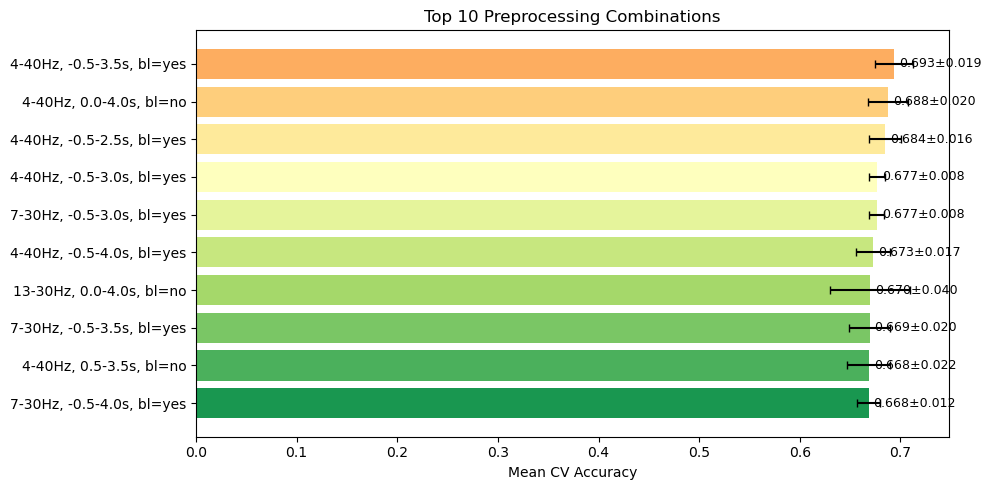

In [131]:
top10 = preproc_df.head(10).copy()
top10['label'] = (top10['low_freq'].astype(int).astype(str) + '-' +
                  top10['high_freq'].astype(int).astype(str) + 'Hz, ' +
                  top10['tmin'].astype(str) + '-' +
                  top10['tmax'].astype(str) + 's, bl=' +
                  top10['baseline'])

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top10)))[::-1]
bars = ax.barh(top10['label'][::-1], top10['mean_acc'][::-1], color=colors)
ax.set_xlabel('Mean CV Accuracy')
ax.set_title('Top 10 Preprocessing Combinations')

ax.errorbar(top10['mean_acc'][::-1], range(len(top10)),
            xerr=top10['std_acc'][::-1], fmt='none', color='black', capsize=3)

for i, (acc, std) in enumerate(zip(top10['mean_acc'][::-1], top10['std_acc'][::-1])):
    ax.text(acc + 0.005, i, f'{acc:.3f}±{std:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


### 18.8 Re-epoch with best preprocessing & validate

Re-run the full pipeline with the best preprocessing params to confirm the improvement.


In [132]:
best = preproc_df.iloc[0]
print(f"Re-epoching with best params:")
print(f"  Bandpass: {best['low_freq']}-{best['high_freq']} Hz")
print(f"  Window:   {best['tmin']} to {best['tmax']}s")
print(f"  Baseline: {best['baseline']}")

baseline_param = (None, 0) if best['baseline'] == 'yes' else None

X_all, y_all, subjects_all = epoch_with_params(
    raw_data,
    low_freq=best['low_freq'],
    high_freq=best['high_freq'],
    tmin=best['tmin'],
    tmax=best['tmax'],
    baseline=baseline_param,
)

time_points = X_all.shape[2]
print(f"\nShape: {X_all.shape} (time_points={time_points})")
print(f"Class distribution: {np.bincount(y_all)}")

# Full 5-fold CV to confirm
print(f"\nRunning full 5-fold CV to confirm...")
mean_acc, std_acc = cv_for_preprocessing(
    X_all, y_all, subjects_all,
    n_splits=5, epochs=50,
)
print(f"\nConfirmed accuracy with best preprocessing: {mean_acc:.4f} ± {std_acc:.4f}")


Re-epoching with best params:
  Bandpass: 4-40 Hz
  Window:   -0.5 to 3.5s
  Baseline: yes

Shape: (4724, 21, 641) (time_points=641)
Class distribution: [2362 2362]

Running full 5-fold CV to confirm...

Confirmed accuracy with best preprocessing: 0.7051 ± 0.0238


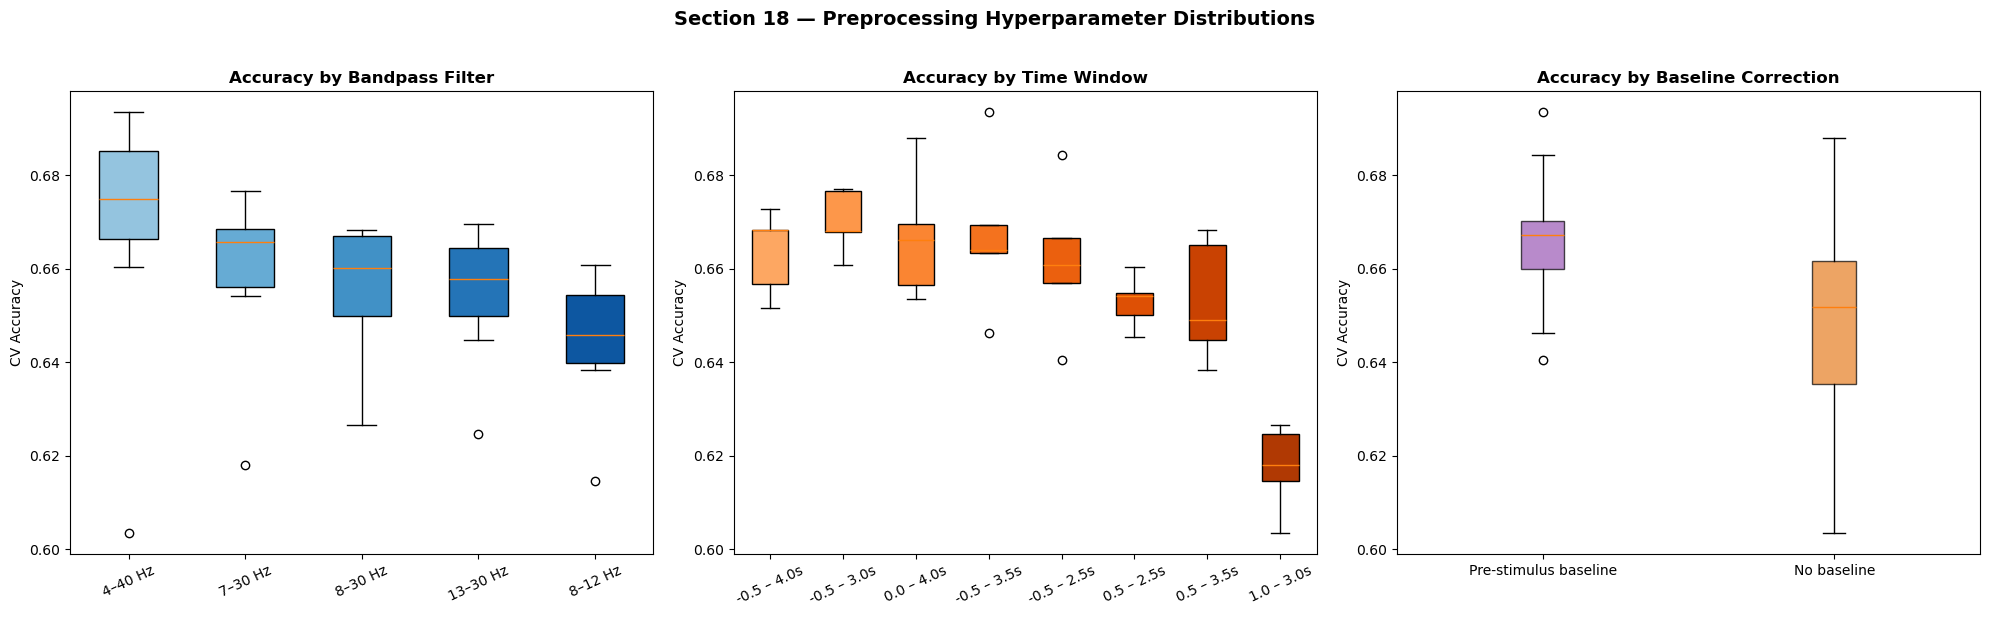

In [133]:
# Prepare labels for plotting
preproc_df_plot = preproc_df.copy()
preproc_df_plot['bandpass'] = (preproc_df_plot['low_freq'].astype(int).astype(str) + '–' +
                               preproc_df_plot['high_freq'].astype(int).astype(str) + ' Hz')
preproc_df_plot['window'] = (preproc_df_plot['tmin'].astype(str) + ' – ' +
                             preproc_df_plot['tmax'].astype(str) + 's')
preproc_df_plot['baseline_label'] = preproc_df_plot['baseline'].map(
    {'no': 'No baseline', 'yes': 'Pre-stimulus baseline'}
)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ── 1. Boxplot by bandpass ──
bp_order = (preproc_df_plot.groupby('bandpass')['mean_acc']
            .median().sort_values(ascending=False).index.tolist())
bp_data = [preproc_df_plot[preproc_df_plot['bandpass'] == bp]['mean_acc'].values
           for bp in bp_order]

bplot1 = axes[0].boxplot(bp_data, vert=True, patch_artist=True, labels=bp_order)
colors1 = plt.cm.Blues(np.linspace(0.4, 0.85, len(bp_order)))
for patch, color in zip(bplot1['boxes'], colors1):
    patch.set_facecolor(color)
axes[0].set_title('Accuracy by Bandpass Filter', fontweight='bold')
axes[0].set_ylabel('CV Accuracy')
axes[0].tick_params(axis='x', rotation=25)

# ── 2. Boxplot by time window ──
tw_order = (preproc_df_plot.groupby('window')['mean_acc']
            .median().sort_values(ascending=False).index.tolist())
tw_data = [preproc_df_plot[preproc_df_plot['window'] == tw]['mean_acc'].values
           for tw in tw_order]

bplot2 = axes[1].boxplot(tw_data, vert=True, patch_artist=True, labels=tw_order)
colors2 = plt.cm.Oranges(np.linspace(0.4, 0.85, len(tw_order)))
for patch, color in zip(bplot2['boxes'], colors2):
    patch.set_facecolor(color)
axes[1].set_title('Accuracy by Time Window', fontweight='bold')
axes[1].set_ylabel('CV Accuracy')
axes[1].tick_params(axis='x', rotation=25)

# ── 3. Boxplot by baseline ──
bl_order = (preproc_df_plot.groupby('baseline_label')['mean_acc']
            .median().sort_values(ascending=False).index.tolist())
bl_data = [preproc_df_plot[preproc_df_plot['baseline_label'] == bl]['mean_acc'].values
           for bl in bl_order]

bplot3 = axes[2].boxplot(bl_data, vert=True, patch_artist=True, labels=bl_order)
colors3 = ['#9b59b6', '#e67e22']
for patch, color in zip(bplot3['boxes'], colors3[:len(bl_order)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[2].set_title('Accuracy by Baseline Correction', fontweight='bold')
axes[2].set_ylabel('CV Accuracy')

plt.suptitle('Section 18 — Preprocessing Hyperparameter Distributions',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

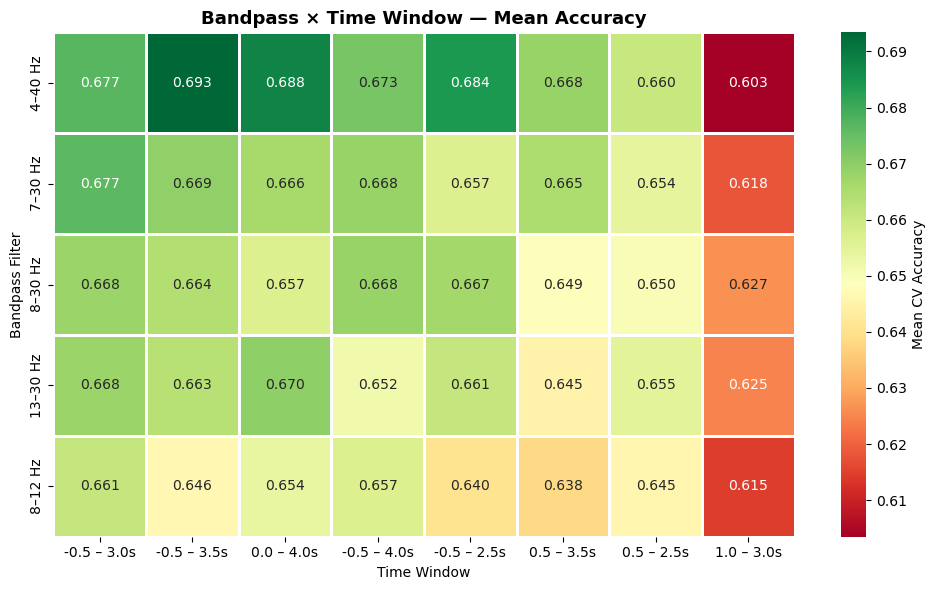

In [134]:
# ── Interaction: bandpass × time window heatmap ──
pivot = preproc_df_plot.pivot_table(
    values='mean_acc', index='bandpass', columns='window', aggfunc='mean'
)

pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]
pivot = pivot[pivot.mean(axis=0).sort_values(ascending=False).index]

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn',
            linewidths=1, linecolor='white', cbar_kws={'label': 'Mean CV Accuracy'})
plt.title('Bandpass × Time Window — Mean Accuracy', fontsize=13, fontweight='bold')
plt.xlabel('Time Window')
plt.ylabel('Bandpass Filter')
plt.tight_layout()
plt.show()

---

# 19. Joint Grid Search — Preprocessing × All Models

We take the **top 5 preprocessing combos** from Section 18 and run the **full model pipeline**
(EEGNet with hyperparameter search + all CSP+ML models) on each.

This is the most comprehensive search in the notebook — it finds the best
(preprocessing, model, hyperparameters) triple.

**Strategy:**

1. Pick top 5 preprocessing combos from Section 18
2. For each: re-epoch → subject-based split → run EEGNet grid search + CSP+ML grid search
3. Collect all results, find the global best
4. Final evaluation on held-out test set


In [135]:
TOP_N = 5

top_preproc = preproc_df.head(TOP_N).copy()
print(f"Top {TOP_N} preprocessing combos from Section 18:")
print("="*80)
for i, row in top_preproc.iterrows():
    print(f"  #{top_preproc.index.get_loc(i)+1}: "
          f"bp={int(row['low_freq'])}-{int(row['high_freq'])}Hz, "
          f"t={row['tmin']}-{row['tmax']}s, "
          f"bl={row['baseline']}, "
          f"acc={row['mean_acc']:.4f}")


Top 5 preprocessing combos from Section 18:
  #1: bp=4-40Hz, t=-0.5-3.5s, bl=yes, acc=0.6934
  #2: bp=4-40Hz, t=0.0-4.0s, bl=no, acc=0.6879
  #3: bp=4-40Hz, t=-0.5-2.5s, bl=yes, acc=0.6843
  #4: bp=4-40Hz, t=-0.5-3.0s, bl=yes, acc=0.6769
  #5: bp=7-30Hz, t=-0.5-3.0s, bl=yes, acc=0.6765


### 19.2 Full pipeline function (EEGNet + CSP + all ML)


In [136]:
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from mne.decoding import CSP
import time


def run_eegnet_grid(X, y, subjects, chans=21, classes=2, n_splits=3, epochs_train=30):
    """
    Run EEGNet hyperparameter grid search with subject-based CV.
    Returns list of {params, mean_acc, std_acc} dicts.
    """
    time_points = X.shape[2]

    param_grid = {
        'lr':           [0.001, 0.0005],
        'dropout_rate': [0.25, 0.5],
        'f1':           [8, 16],
        'd':            [2],
    }

    keys = list(param_grid.keys())
    combos = list(itertools.product(*param_grid.values()))

    results = []
    for combo in combos:
        params = dict(zip(keys, combo))
        f2 = params['f1'] * params['d']

        gkf = GroupKFold(n_splits=n_splits)
        fold_accs = []

        for train_idx, val_idx in gkf.split(X, y, groups=subjects):
            X_tr, y_tr = X[train_idx], y[train_idx]
            X_vl, y_vl = X[val_idx], y[val_idx]

            train_dl = DataLoader(EEGDataset(X_tr, y_tr), batch_size=64, shuffle=True)
            val_dl   = DataLoader(EEGDataset(X_vl, y_vl), batch_size=64, shuffle=False)

            model = EEGNet(chans=chans, classes=classes, time_points=time_points,
                           f1=params['f1'], f2=f2, d=params['d'],
                           dropout_rate=params['dropout_rate']).to(device)
            optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'])

            weights = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
            loss_fn = nn.CrossEntropyLoss(
                weight=torch.tensor(weights, dtype=torch.float32).to(device))

            best_val = 0.0
            for _ in range(epochs_train):
                train_step(model, train_dl, loss_fn, optimizer, device)
                _, val_acc = eval_step(model, val_dl, loss_fn, device)
                if val_acc > best_val:
                    best_val = val_acc
            fold_accs.append(best_val)

        results.append({
            'model_type': 'EEGNet',
            'model_name': f"EEGNet(f1={params['f1']},d={params['d']},do={params['dropout_rate']},lr={params['lr']})",
            'mean_acc': np.mean(fold_accs),
            'std_acc': np.std(fold_accs),
            'params': {**params, 'f2': f2},
        })

    return results


def run_ml_grid(X, y, subjects, n_splits=3):
    """
    Run CSP + all ML models grid search with subject-based CV.
    Returns list of {model_name, mean_acc, std_acc} dicts.
    """
    gkf = GroupKFold(n_splits=n_splits)

    models = {
        'LDA': {
            'model': LinearDiscriminantAnalysis(),
            'params': [
                {'classifier__solver': ['svd'], 'classifier__shrinkage': [None],
                 'csp__n_components': [4, 6]},
                {'classifier__solver': ['lsqr'], 'classifier__shrinkage': [None, 'auto'],
                 'csp__n_components': [4, 6]},
            ]
        },
        'SVM': {
            'model': SVC(probability=True, random_state=42, class_weight='balanced'),
            'params': {
                'classifier__C': [0.1, 1.0, 10.0],
                'classifier__kernel': ['rbf', 'linear'],
                'csp__n_components': [4, 6],
            }
        },
        'RandomForest': {
            'model': RandomForestClassifier(random_state=42, class_weight='balanced'),
            'params': {
                'classifier__n_estimators': [100, 200],
                'classifier__max_depth': [5, 10, None],
                'csp__n_components': [4, 6],
            }
        },
        'KNN': {
            'model': KNeighborsClassifier(),
            'params': {
                'classifier__n_neighbors': [3, 5, 7],
                'classifier__weights': ['uniform', 'distance'],
                'csp__n_components': [4, 6],
            }
        },
        'GradientBoosting': {
            'model': GradientBoostingClassifier(random_state=42),
            'params': {
                'classifier__n_estimators': [100, 200],
                'classifier__learning_rate': [0.01, 0.1],
                'classifier__max_depth': [3, 5],
                'csp__n_components': [4, 6],
            }
        },
        'LogisticRegression': {
            'model': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
            'params': {
                'classifier__C': [0.1, 1.0, 10.0],
                'classifier__penalty': ['l1', 'l2'],
                'classifier__solver': ['saga'],
                'csp__n_components': [4, 6],
            }
        },
        'MLP': {
            'model': MLPClassifier(max_iter=500, random_state=42, early_stopping=True),
            'params': {
                'classifier__hidden_layer_sizes': [(64,), (128,)],
                'classifier__alpha': [0.0001, 0.001],
                'csp__n_components': [4, 6],
            }
        },
    }

    results = []
    for name, config in models.items():
        pipe = Pipeline([
            ('csp', CSP(n_components=4, reg='ledoit_wolf', log=True, norm_trace=False)),
            ('scaler', StandardScaler()),
            ('classifier', config['model']),
        ])

        grid = GridSearchCV(
            pipe, param_grid=config['params'],
            cv=gkf, scoring='accuracy', n_jobs=-1, verbose=0, error_score='raise',
        )

        try:
            grid.fit(X, y, groups=subjects)
            results.append({
                'model_type': 'CSP+ML',
                'model_name': f'CSP+{name}',
                'mean_acc': grid.best_score_,
                'std_acc': grid.cv_results_['std_test_score'][grid.best_index_],
                'params': grid.best_params_,
                'grid_obj': grid,
            })
        except Exception as e:
            print(f"  ✗ {name} failed: {e}")

    return results

print("Pipeline functions ready.")


Pipeline functions ready.


### 19.3 Run joint grid search


In [137]:
all_joint_results = []

for pp_idx, (_, pp_row) in enumerate(top_preproc.iterrows()):
    pp_label = (f"bp={int(pp_row['low_freq'])}-{int(pp_row['high_freq'])}Hz, "
               f"t={pp_row['tmin']}-{pp_row['tmax']}s, bl={pp_row['baseline']}")

    print(f"\n{'='*70}")
    print(f"  PREPROCESSING {pp_idx+1}/{TOP_N}: {pp_label}")
    print(f"{'='*70}")

    baseline_param = (None, 0) if pp_row['baseline'] == 'yes' else None

    X, y, subjects = epoch_with_params(
        raw_data,
        low_freq=pp_row['low_freq'],
        high_freq=pp_row['high_freq'],
        tmin=pp_row['tmin'],
        tmax=pp_row['tmax'],
        baseline=baseline_param,
    )
    print(f"  Epoched: {X.shape}, classes: {np.bincount(y)}")

    print(f"\n  Running EEGNet grid search...")
    start = time.time()
    eegnet_results = run_eegnet_grid(X, y, subjects)
    print(f"  EEGNet done ({time.time()-start:.0f}s), "
          f"best: {max(r['mean_acc'] for r in eegnet_results):.4f}")

    print(f"  Running CSP+ML grid search...")
    start = time.time()
    ml_results = run_ml_grid(X, y, subjects)
    print(f"  CSP+ML done ({time.time()-start:.0f}s), "
          f"best: {max(r['mean_acc'] for r in ml_results):.4f}")

    for r in eegnet_results + ml_results:
        all_joint_results.append({
            'preproc': pp_label,
            'low_freq': pp_row['low_freq'],
            'high_freq': pp_row['high_freq'],
            'tmin': pp_row['tmin'],
            'tmax': pp_row['tmax'],
            'baseline': pp_row['baseline'],
            'model_type': r['model_type'],
            'model_name': r['model_name'],
            'mean_acc': r['mean_acc'],
            'std_acc': r['std_acc'],
        })

print(f"\n{'='*70}")
print(f"Total results: {len(all_joint_results)}")



  PREPROCESSING 1/5: bp=4-40Hz, t=-0.5-3.5s, bl=yes
  Epoched: (4724, 21, 641), classes: [2362 2362]

  Running EEGNet grid search...
  EEGNet done (170s), best: 0.7081
  Running CSP+ML grid search...
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
    Using tolerance 27 (2.2e-16 eps * 21 dim * 5.8e+15  max singular value)
  

### 19.4 Full results table


In [138]:
joint_df = pd.DataFrame(all_joint_results)
joint_df = joint_df.sort_values('mean_acc', ascending=False)

print("Top 20 (Preprocessing × Model) Combinations:")
print("="*100)
print(joint_df.head(20)[['preproc', 'model_name', 'mean_acc', 'std_acc']].to_string(index=False))

print(f"\n{'='*100}")
best = joint_df.iloc[0]
print(f"\n🏆 GLOBAL BEST:")
print(f"  Preprocessing: {best['preproc']}")
print(f"  Model:         {best['model_name']}")
print(f"  Accuracy:      {best['mean_acc']:.4f} ± {best['std_acc']:.4f}")

Top 20 (Preprocessing × Model) Combinations:
                       preproc                          model_name  mean_acc  std_acc
  bp=4-40Hz, t=0.0-4.0s, bl=no  EEGNet(f1=16,d=2,do=0.25,lr=0.001)  0.752902 0.012093
  bp=4-40Hz, t=0.0-4.0s, bl=no   EEGNet(f1=8,d=2,do=0.25,lr=0.001)  0.736234 0.041889
bp=4-40Hz, t=-0.5-3.5s, bl=yes   EEGNet(f1=8,d=2,do=0.25,lr=0.001)  0.708087 0.005589
bp=4-40Hz, t=-0.5-2.5s, bl=yes  EEGNet(f1=16,d=2,do=0.25,lr=0.001)  0.707730 0.004162
bp=4-40Hz, t=-0.5-3.0s, bl=yes   EEGNet(f1=8,d=2,do=0.25,lr=0.001)  0.701810 0.023801
bp=4-40Hz, t=-0.5-3.5s, bl=yes  EEGNet(f1=16,d=2,do=0.25,lr=0.001)  0.700465 0.013484
bp=4-40Hz, t=-0.5-2.5s, bl=yes   EEGNet(f1=8,d=2,do=0.25,lr=0.001)  0.698637 0.006693
  bp=4-40Hz, t=0.0-4.0s, bl=no   EEGNet(f1=16,d=2,do=0.5,lr=0.001)  0.696931 0.013912
bp=4-40Hz, t=-0.5-2.5s, bl=yes   EEGNet(f1=16,d=2,do=0.5,lr=0.001)  0.696437 0.002574
bp=4-40Hz, t=-0.5-2.5s, bl=yes EEGNet(f1=16,d=2,do=0.25,lr=0.0005)  0.696257 0.011037
bp=4-40Hz

### 19.5 Analysis plots


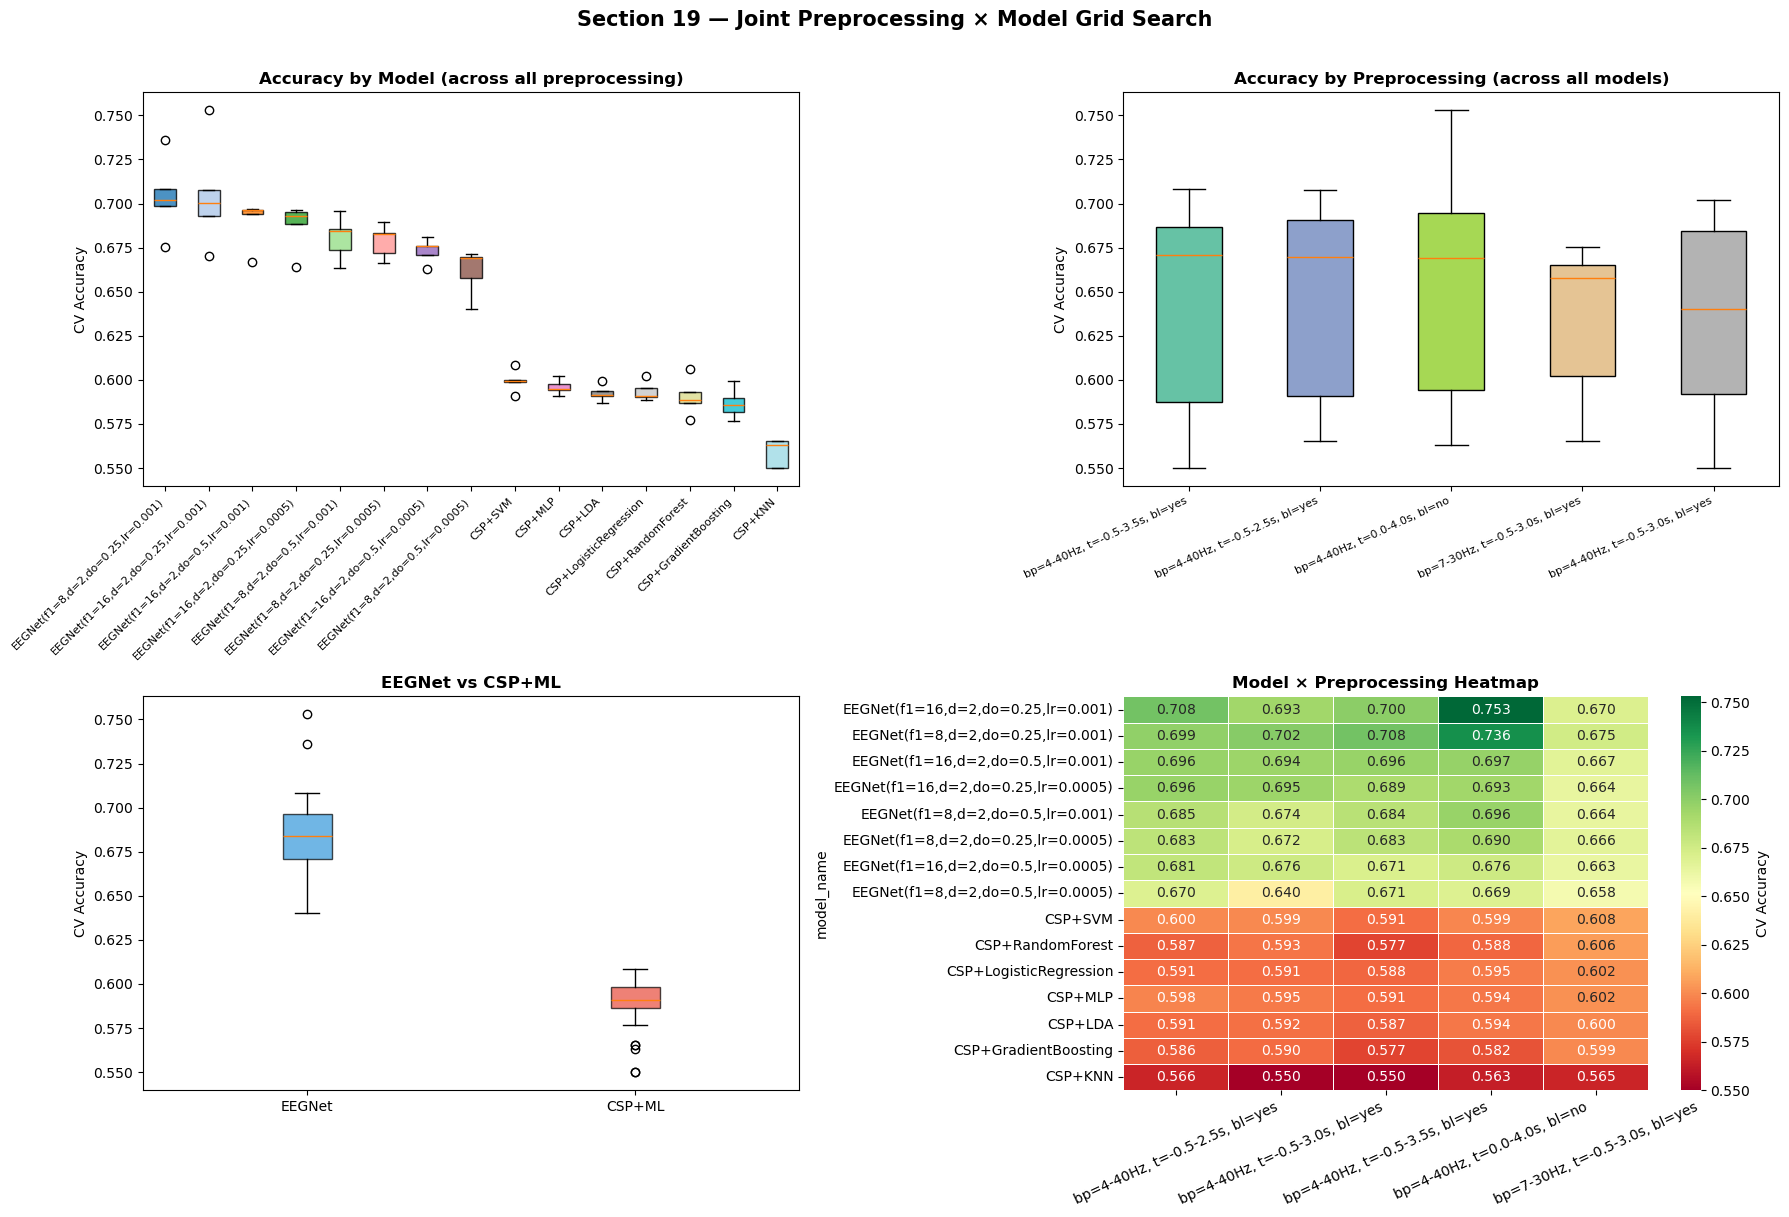

In [139]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

model_order = (joint_df.groupby('model_name')['mean_acc']
               .median().sort_values(ascending=False).index.tolist())
model_data = [joint_df[joint_df['model_name'] == m]['mean_acc'].values for m in model_order]

bplot1 = axes[0, 0].boxplot(model_data, vert=True, patch_artist=True)
colors1 = plt.cm.tab20(np.linspace(0, 1, len(model_order)))
for patch, color in zip(bplot1['boxes'], colors1):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[0, 0].set_xticklabels(model_order, rotation=45, ha='right', fontsize=8)
axes[0, 0].set_title('Accuracy by Model (across all preprocessing)', fontweight='bold')
axes[0, 0].set_ylabel('CV Accuracy')

pp_order = (joint_df.groupby('preproc')['mean_acc']
            .median().sort_values(ascending=False).index.tolist())
pp_data = [joint_df[joint_df['preproc'] == p]['mean_acc'].values for p in pp_order]

bplot2 = axes[0, 1].boxplot(pp_data, vert=True, patch_artist=True)
colors2 = plt.cm.Set2(np.linspace(0, 1, len(pp_order)))
for patch, color in zip(bplot2['boxes'], colors2):
    patch.set_facecolor(color)
axes[0, 1].set_xticklabels(pp_order, rotation=25, ha='right', fontsize=8)
axes[0, 1].set_title('Accuracy by Preprocessing (across all models)', fontweight='bold')
axes[0, 1].set_ylabel('CV Accuracy')

type_order = ['EEGNet', 'CSP+ML']
type_data = [joint_df[joint_df['model_type'] == t]['mean_acc'].values for t in type_order]

bplot3 = axes[1, 0].boxplot(type_data, vert=True, patch_artist=True, labels=type_order)
for patch, color in zip(bplot3['boxes'], ['#3498db', '#e74c3c']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1, 0].set_title('EEGNet vs CSP+ML', fontweight='bold')
axes[1, 0].set_ylabel('CV Accuracy')

pivot = joint_df.pivot_table(
    values='mean_acc', index='model_name', columns='preproc', aggfunc='max'
)
pivot = pivot.loc[pivot.max(axis=1).sort_values(ascending=False).index]

sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn',
            linewidths=0.5, ax=axes[1, 1], cbar_kws={'label': 'CV Accuracy'})
axes[1, 1].set_title('Model × Preprocessing Heatmap', fontweight='bold')
axes[1, 1].set_xlabel('')
axes[1, 1].tick_params(axis='x', rotation=25)
axes[1, 1].tick_params(axis='y', rotation=0)

plt.suptitle('Section 19 — Joint Preprocessing × Model Grid Search',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


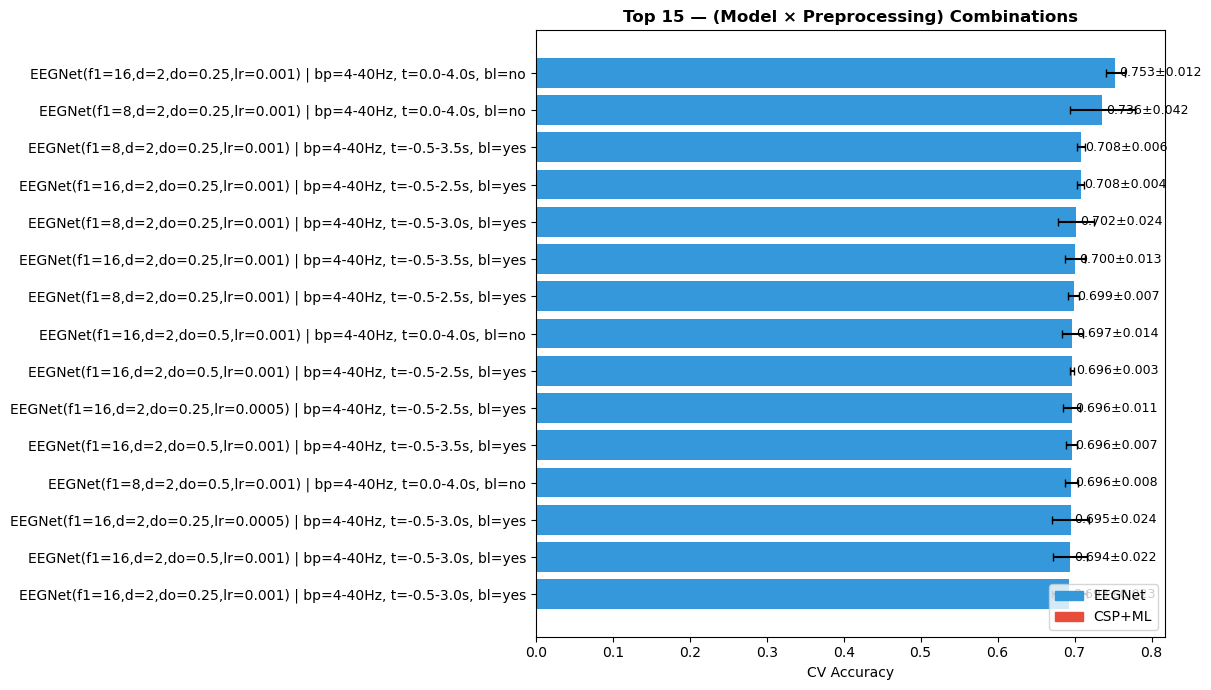

In [140]:
top15 = joint_df.head(15).copy()
top15['label'] = top15['model_name'] + ' | ' + top15['preproc']

fig, ax = plt.subplots(figsize=(12, 7))

colors = ['#3498db' if t == 'EEGNet' else '#e74c3c' for t in top15['model_type']]

bars = ax.barh(top15['label'][::-1], top15['mean_acc'][::-1], color=colors[::-1])
ax.errorbar(top15['mean_acc'][::-1], range(len(top15)),
            xerr=top15['std_acc'][::-1], fmt='none', color='black', capsize=3)

for i, (acc, std) in enumerate(zip(top15['mean_acc'][::-1], top15['std_acc'][::-1])):
    ax.text(acc + 0.005, i, f'{acc:.3f}±{std:.3f}', va='center', fontsize=9)

ax.set_xlabel('CV Accuracy')
ax.set_title('Top 15 — (Model × Preprocessing) Combinations', fontweight='bold')

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#3498db', label='EEGNet'),
                   Patch(color='#e74c3c', label='CSP+ML')],
          loc='lower right')

plt.tight_layout()
plt.show()


### 19.6 Final evaluation — retrain best combo on train+val, test on held-out

Take the global best (preprocessing × model) and do a proper final evaluation.


Global best: EEGNet(f1=16,d=2,do=0.25,lr=0.001) with bp=4-40Hz, t=0.0-4.0s, bl=no
CV Accuracy: 0.7529 ± 0.0121

Train: 3292, Val: 662, Test: 750
Train dist: [1649 1643], Test dist: [375 375]


  1%|          | 1/100 [00:00<00:29,  3.32it/s]

Epoch:   1 | train_loss: 0.7004 | train_acc: 0.5027 | val_loss: 0.6950 | val_acc: 0.5066


  2%|▏         | 2/100 [00:00<00:29,  3.32it/s]

Epoch:   2 | train_loss: 0.6816 | train_acc: 0.5629 | val_loss: 0.6799 | val_acc: 0.5690


...

Epoch:  98 | train_loss: 0.2857 | train_acc: 0.8834 | val_loss: 0.5465 | val_acc: 0.7845


 99%|█████████▉| 99/100 [00:29<00:00,  3.31it/s]

Epoch:  99 | train_loss: 0.2781 | train_acc: 0.8803 | val_loss: 0.5423 | val_acc: 0.7845


100%|██████████| 100/100 [00:30<00:00,  3.32it/s]

Epoch: 100 | train_loss: 0.2833 | train_acc: 0.8790 | val_loss: 0.5481 | val_acc: 0.7832

Best val_acc: 0.8037
Final test_loss: 0.5367 | test_acc: 0.8037

  FINAL TEST RESULTS — Section 19
Test Accuracy: 0.8027
              precision    recall  f1-score   support

   left_hand       0.82      0.78      0.80       375
  right_hand       0.79      0.82      0.81       375

    accuracy                           0.80       750
   macro avg       0.80      0.80      0.80       750
weighted avg       0.80      0.80      0.80       750



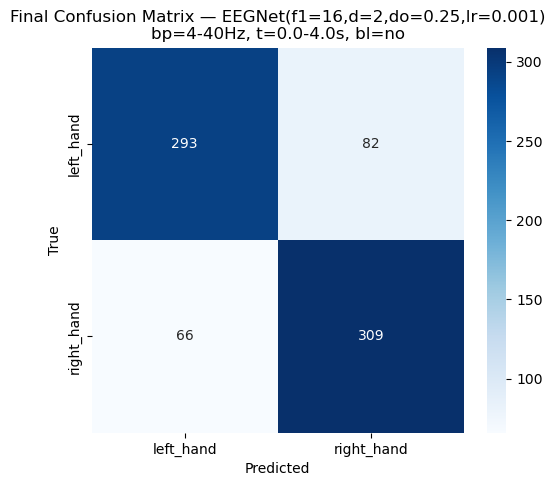

In [141]:
best = joint_df.iloc[0]
print(f"Global best: {best['model_name']} with {best['preproc']}")
print(f"CV Accuracy: {best['mean_acc']:.4f} ± {best['std_acc']:.4f}")

baseline_param = (None, 0) if best['baseline'] == 'yes' else None
X_all, y_all, subjects_all = epoch_with_params(
    raw_data,
    low_freq=best['low_freq'], high_freq=best['high_freq'],
    tmin=best['tmin'], tmax=best['tmax'],
    baseline=baseline_param,
)

unique_subjects = np.unique(subjects_all)
np.random.shuffle(unique_subjects)
n = len(unique_subjects)
n_train = int(n * 0.7)
n_val = int(n * 0.15)

train_subjects = set(unique_subjects[:n_train])
val_subjects   = set(unique_subjects[n_train:n_train + n_val])
test_subjects  = set(unique_subjects[n_train + n_val:])

train_mask = np.isin(subjects_all, list(train_subjects))
val_mask   = np.isin(subjects_all, list(val_subjects))
test_mask  = np.isin(subjects_all, list(test_subjects))

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_val,   y_val   = X_all[val_mask],   y_all[val_mask]
X_test,  y_test  = X_all[test_mask],  y_all[test_mask]

print(f"\nTrain: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")
print(f"Train dist: {np.bincount(y_train)}, Test dist: {np.bincount(y_test)}")

if best['model_type'] == 'EEGNet':
    time_points = X_all.shape[2]
    X_trainval = np.concatenate([X_train, X_val])
    y_trainval = np.concatenate([y_train, y_val])

    trainval_dl = DataLoader(EEGDataset(X_trainval, y_trainval), batch_size=64, shuffle=True)
    test_dl = DataLoader(EEGDataset(X_test, y_test), batch_size=64, shuffle=False)

    best_eegnet_row = joint_df[joint_df['model_type'] == 'EEGNet'].iloc[0]
    
    import re
    m = re.search(r'f1=(\d+),d=(\d+),do=([\d.]+),lr=([\d.]+)', best_eegnet_row['model_name'])
    f1, d, do, lr = int(m.group(1)), int(m.group(2)), float(m.group(3)), float(m.group(4))
    f2 = f1 * d

    final_model = EEGNet(chans=21, classes=2, time_points=time_points,
                         f1=f1, f2=f2, d=d, dropout_rate=do).to(device)
    optimizer = torch.optim.Adam(final_model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

    weights = compute_class_weight('balanced', classes=np.unique(y_trainval), y=y_trainval)
    loss_fn = nn.CrossEntropyLoss(
        weight=torch.tensor(weights, dtype=torch.float32).to(device))

    final_results, _ = train(
        model=final_model, train_dataloader=trainval_dl,
        val_dataloader=test_dl, test_dataloader=test_dl,
        optimizer=optimizer, loss_fn=loss_fn,
        scheduler=scheduler, device=device, epochs=100
    )

    final_model.eval()
    all_preds, all_labels = [], []
    with torch.inference_mode():
        for X_batch, y_batch in test_dl:
            preds = final_model(X_batch.to(device)).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())

else:
    X_trainval = np.concatenate([X_train, X_val])
    y_trainval = np.concatenate([y_train, y_val])

    best_ml_name = best['model_name'].replace('CSP+', '')
    ml_models_map = {
        'LDA': LinearDiscriminantAnalysis(),
        'SVM': SVC(probability=True, random_state=42, class_weight='balanced'),
        'RandomForest': RandomForestClassifier(random_state=42, class_weight='balanced'),
        'KNN': KNeighborsClassifier(),
        'GradientBoosting': GradientBoostingClassifier(random_state=42),
        'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
        'MLP': MLPClassifier(max_iter=500, random_state=42, early_stopping=True),
    }

    pipe = Pipeline([
        ('csp', CSP(n_components=6, reg='ledoit_wolf', log=True, norm_trace=False)),
        ('scaler', StandardScaler()),
        ('classifier', ml_models_map[best_ml_name]),
    ])
    pipe.fit(X_trainval, y_trainval)

    all_preds = pipe.predict(X_test)
    all_labels = y_test

print(f"\n{'='*60}")
print(f"  FINAL TEST RESULTS — Section 19")
print(f"{'='*60}")
print(f"Test Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
print(classification_report(all_labels, all_preds,
                            target_names=['left_hand', 'right_hand']))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['left_hand', 'right_hand'],
            yticklabels=['left_hand', 'right_hand'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Final Confusion Matrix — {best["model_name"]}\n{best["preproc"]}')
plt.show()